# Анализ результатов экспериментов

In [22]:
import sys, os
from pathlib import Path


EXPERIMENTS = {
    "RU Simple 1:1:1":  {"path": "model_utils/sweeps3", "lang": "RU", "head": "Simple",  "weights": "1:1:1"},
    "RU Simple 3:3:1":  {"path": "model_utils/sweeps4", "lang": "RU", "head": "Simple",  "weights": "3:3:1"},
    "EN Simple 1:1:1":  {"path": "model_utils/sweeps5", "lang": "EN", "head": "Simple",  "weights": "1:1:1"},
    "EN Simple 3:3:1":  {"path": "model_utils/sweeps6", "lang": "EN", "head": "Simple",  "weights": "3:3:1"},
    "RU Complex 3:3:1": {"path": "model_utils/sweeps7","lang": "RU", "head": "Complex", "weights": "3:3:1"},
}

MODEL_UTILS_DIR = os.path.abspath("model_utils")
if MODEL_UTILS_DIR not in sys.path:
    sys.path.insert(0, MODEL_UTILS_DIR)


OUTPUT_DIR = Path("analysis_output")
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / "plots").mkdir(exist_ok=True)
(OUTPUT_DIR / "tables").mkdir(exist_ok=True)


MODEL_SHORT_NAMES = {
    "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli": "DeBERTa-v3",
    "BAAI/bge-m3": "BGE-M3",
    "deepvk/RuModernBERT-base": "ModernBERT",
}

TARGETS = ["relevance", "utilization", "adherence"]
TARGETS_RU = {"relevance": "relevance", "utilization": "utilization", "adherence": "adherence"}
F1_COLS = [f"{t}_f1" for t in TARGETS]
TEST_F1_COLS = [f"test_{t}_f1" for t in TARGETS]
P_COLS = [f"{t}_precision" for t in TARGETS]
R_COLS = [f"{t}_recall" for t in TARGETS]

print("Output dir:", OUTPUT_DIR.resolve())
print("Экспериментов сконфигурировано:", len(EXPERIMENTS))

Output dir: /workdir/ruRagEvaluation_new/analysis_output
Экспериментов сконфигурировано: 5


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

from results import load_results_from_dirs


frames = []
for exp_name, meta in EXPERIMENTS.items():
    sweep_path = meta["path"]
    if not os.path.isdir(sweep_path):
        print(f"[!] Не найдена папка {sweep_path}, пропускаю {exp_name}")
        continue
    df = load_results_from_dirs(sweep_path)
    if df.empty:
        print(f"[!] Нет result.json в {sweep_path}, пропускаю {exp_name}")
        continue
    df["experiment"] = exp_name
    df["lang"] = meta["lang"]
    df["head_type"] = meta["head"]
    df["weights"] = meta["weights"]
    df["model_short"] = df["model_name"].map(MODEL_SHORT_NAMES).fillna(df["model_name"])
    frames.append(df)
    print(f"[+] {exp_name}: {len(df)} экспериментов загружено")

df_all = pd.concat(frames, ignore_index=True)
print(f"\nВсего загружено: {len(df_all)} запусков")
print(f"Эксперименты: {df_all['experiment'].unique().tolist()}")
print(f"Языки:        {df_all['lang'].unique().tolist()}")
print(f"Головы:       {df_all['head_type'].unique().tolist()}")
print(f"Веса:         {df_all['weights'].unique().tolist()}")
print(f"Модели:       {df_all['model_short'].unique().tolist()}")
print(f"Длины:        {sorted(df_all['max_length'].unique().tolist())}")
df_all.head()

[+] RU Simple 1:1:1: 15 экспериментов загружено
[+] RU Simple 3:3:1: 15 экспериментов загружено
[+] EN Simple 1:1:1: 17 экспериментов загружено
[+] EN Simple 3:3:1: 17 экспериментов загружено
[+] RU Complex 3:3:1: 17 экспериментов загружено

Всего загружено: 81 запусков
Эксперименты: ['RU Simple 1:1:1', 'RU Simple 3:3:1', 'EN Simple 1:1:1', 'EN Simple 3:3:1', 'RU Complex 3:3:1']
Языки:        ['RU', 'EN']
Головы:       ['Simple', 'Complex']
Веса:         ['1:1:1', '3:3:1']
Модели:       ['BGE-M3', 'DeBERTa-v3', 'ModernBERT', 'Tochka-AI/ruRoPEBert-e5-base-2k']
Длины:        [128, 256, 512, 1024, 2048, 4096, 8192]


,run_id,model_name,max_length,output_dir,best_val_f1,timestamp,relevance_precision,relevance_recall,relevance_f1,utilization_precision,...,threshold_utilization,threshold_adherence,n_train,n_validation,n_test,experiment,lang,head_type,weights,model_short
0,20260406_225304,BAAI/bge-m3,1024,sweeps3/BAAI__bge-m3/len_1024,0.787488,2026-04-06T22:53:04.751517,0.786469,0.788510,0.787488,0.826893,...,0.4,0.1,9775,1569,2528,RU Simple 1:1:1,RU,Simple,1:1:1,BGE-M3
1,20260407_002838,BAAI/bge-m3,2048,sweeps3/BAAI__bge-m3/len_2048,0.800801,2026-04-07T00:28:38.838379,0.795938,0.805724,0.800801,0.854071,...,0.5,0.1,20621,3115,4541,RU Simple 1:1:1,RU,Simple,1:1:1,BGE-M3
2,20260406_222353,BAAI/bge-m3,256,sweeps3/BAAI__bge-m3/len_256,0.736388,2026-04-06T22:23:53.159821,0.723040,0.750239,0.736388,0.680712,...,0.2,0.1,661,88,322,RU Simple 1:1:1,RU,Simple,1:1:1,BGE-M3
3,20260407_024107,BAAI/bge-m3,4096,sweeps3/BAAI__bge-m3/len_4096,0.790120,2026-04-07T02:41:07.710575,0.789133,0.791109,0.790120,0.845079,...,0.5,0.1,21652,3256,4758,RU Simple 1:1:1,RU,Simple,1:1:1,BGE-M3
4,20260406_222822,BAAI/bge-m3,512,sweeps3/BAAI__bge-m3/len_512,0.788973,2026-04-06T22:28:22.726795,0.764779,0.814747,0.788973,0.785154,...,0.4,0.1,2657,378,898,RU Simple 1:1:1,RU,Simple,1:1:1,BGE-M3


In [39]:
df_all[df_all.output_dir.isin(['sweeps3/BAAI__bge-m3/len_1024', 'sweeps4/BAAI__bge-m3/len_1024'])]

,run_id,model_name,max_length,output_dir,best_val_f1,timestamp,relevance_precision,relevance_recall,relevance_f1,utilization_precision,...,threshold_utilization,threshold_adherence,n_train,n_validation,n_test,experiment,lang,head_type,weights,model_short
0,20260406_225304,BAAI/bge-m3,1024,sweeps3/BAAI__bge-m3/len_1024,0.787488,2026-04-06T22:53:04.751517,0.786469,0.78851,0.787488,0.826893,...,0.4,0.1,9775,1569,2528,RU Simple 1:1:1,RU,Simple,1:1:1,BGE-M3
15,20260407_143817,BAAI/bge-m3,1024,sweeps4/BAAI__bge-m3/len_1024,0.785542,2026-04-07T14:38:17.371452,0.784358,0.78673,0.785542,0.816838,...,0.4,0.2,9775,1569,2528,RU Simple 3:3:1,RU,Simple,3:3:1,BGE-M3


## 2. Лучшая конфигурация для каждой модели (по val F1)

In [24]:

idx_best = df_all.groupby(["experiment", "model_short"])["best_val_f1"].idxmax()
df_best = df_all.loc[idx_best].copy()

show_cols = [
    "experiment", "lang", "head_type", "weights",
    "model_short", "max_length", "best_val_f1",
    *F1_COLS,
    *TEST_F1_COLS,
    "threshold_relevance", "threshold_utilization", "threshold_adherence",
]
show_cols = [c for c in show_cols if c in df_best.columns]

df_best_show = (
    df_best[show_cols]
    .sort_values(["lang", "head_type", "weights", "best_val_f1"],
                 ascending=[True, True, True, False])
    .reset_index(drop=True)
)

numeric_cols = [c for c in show_cols
                if c not in ["experiment", "lang", "head_type", "weights", "model_short", "max_length"]]
grad_cols = [c for c in F1_COLS + TEST_F1_COLS if c in show_cols]

styled = (
    df_best_show.style
    .format("{:.4f}", subset=numeric_cols)
    .background_gradient(cmap="RdYlGn", subset=grad_cols, vmin=0, vmax=1)
    .set_caption("Лучшая конфигурация каждой модели по val F1")
)
df_best_show.to_csv(OUTPUT_DIR / "tables" / "best_config_per_model.csv", index=False)
styled

,experiment,lang,head_type,weights,model_short,max_length,best_val_f1,relevance_f1,utilization_f1,adherence_f1,test_relevance_f1,test_utilization_f1,test_adherence_f1,threshold_relevance,threshold_utilization,threshold_adherence
0,EN Simple 1:1:1,EN,Simple,1:1:1,DeBERTa-v3,128,0.7684,0.7684,0.6697,0.9027,0.6399,0.5458,0.8913,0.1000,0.1000,0.1000
1,EN Simple 1:1:1,EN,Simple,1:1:1,ModernBERT,1024,0.6576,0.6576,0.6562,0.9291,0.6299,0.6267,0.9167,0.4000,0.4000,0.6000
2,EN Simple 1:1:1,EN,Simple,1:1:1,Tochka-AI/ruRoPEBert-e5-base-2k,256,0.6357,0.6357,0.5398,0.9215,0.5581,0.4706,0.9091,0.1000,0.1000,0.1000
3,EN Simple 1:1:1,EN,Simple,1:1:1,BGE-M3,512,0.4882,0.4882,0.4065,0.8821,0.4801,0.4122,0.9147,0.1000,0.1000,0.1000
4,EN Simple 3:3:1,EN,Simple,3:3:1,DeBERTa-v3,128,0.7686,0.7686,0.0000,0.9027,0.6399,0.0000,0.8913,0.1000,0.1000,0.1000
5,EN Simple 3:3:1,EN,Simple,3:3:1,ModernBERT,1024,0.6644,0.6644,0.6693,0.9324,0.6589,0.6590,0.9222,0.4000,0.5000,0.3000
6,EN Simple 3:3:1,EN,Simple,3:3:1,Tochka-AI/ruRoPEBert-e5-base-2k,256,0.6357,0.6357,0.5398,0.9215,0.5581,0.4706,0.9091,0.1000,0.1000,0.1000
7,EN Simple 3:3:1,EN,Simple,3:3:1,BGE-M3,512,0.4882,0.4882,0.4065,0.8821,0.4804,0.4126,0.9148,0.1000,0.1000,0.1000
8,RU Complex 3:3:1,RU,Complex,3:3:1,DeBERTa-v3,128,0.9519,0.9519,0.8821,0.8614,0.8869,0.7519,0.8700,0.1000,0.1000,0.1000
9,RU Complex 3:3:1,RU,Complex,3:3:1,Tochka-AI/ruRoPEBert-e5-base-2k,256,0.6534,0.6534,0.5610,0.9393,0.5637,0.4696,0.9039,0.1000,0.1000,0.1000


## 3. Полная сетка: Test F1 по всем (модель, длина, эксперимент)

In [25]:

f1_source = TEST_F1_COLS if all(c in df_all.columns for c in TEST_F1_COLS) else F1_COLS
f1_label = "test" if f1_source == TEST_F1_COLS else "val"

exp_order = list(EXPERIMENTS.keys())
exp_order = [e for e in exp_order if e in df_all["experiment"].unique()]

for target in TARGETS:
    col = f"test_{target}_f1" if f"test_{target}_f1" in df_all.columns else f"{target}_f1"
    pivot = df_all.pivot_table(
        index=["model_short", "max_length"],
        columns="experiment",
        values=col,
        aggfunc="first",
    ).round(4)
    pivot = pivot.reindex(columns=[e for e in exp_order if e in pivot.columns])

    print(f"\n{'='*70}")
    print(f"  Полная сетка — {TARGETS_RU[target]} ({target}) F1 [{f1_label}]")
    print(f"{'='*70}")
    display(pivot.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1).format("{:.4f}"))

    csv_path = OUTPUT_DIR / "tables" / f"grid_{target}_f1.csv"
    pivot.to_csv(csv_path)


full_cols = ["experiment", "lang", "head_type", "weights", "model_short", "max_length"] + F1_COLS
if TEST_F1_COLS[0] in df_all.columns:
    full_cols += TEST_F1_COLS
full_cols = [c for c in full_cols if c in df_all.columns]

df_grid = (
    df_all[full_cols]
    .sort_values(["lang", "head_type", "weights", "model_short", "max_length"])
    .reset_index(drop=True)
)
df_grid.to_csv(OUTPUT_DIR / "tables" / "full_grid.csv", index=False)
print(f"\nСохранено в {OUTPUT_DIR / 'tables' / 'full_grid.csv'}")


  Полная сетка — relevance (relevance) F1 [test]



  Полная сетка — utilization (utilization) F1 [test]



  Полная сетка — adherence (adherence) F1 [test]



Сохранено в analysis_output/tables/full_grid.csv


## 4. Графики: F1 vs длина контекста (по эксперименту)

Saved: analysis_output/plots/f1_vs_length_RU_Simple_111.png


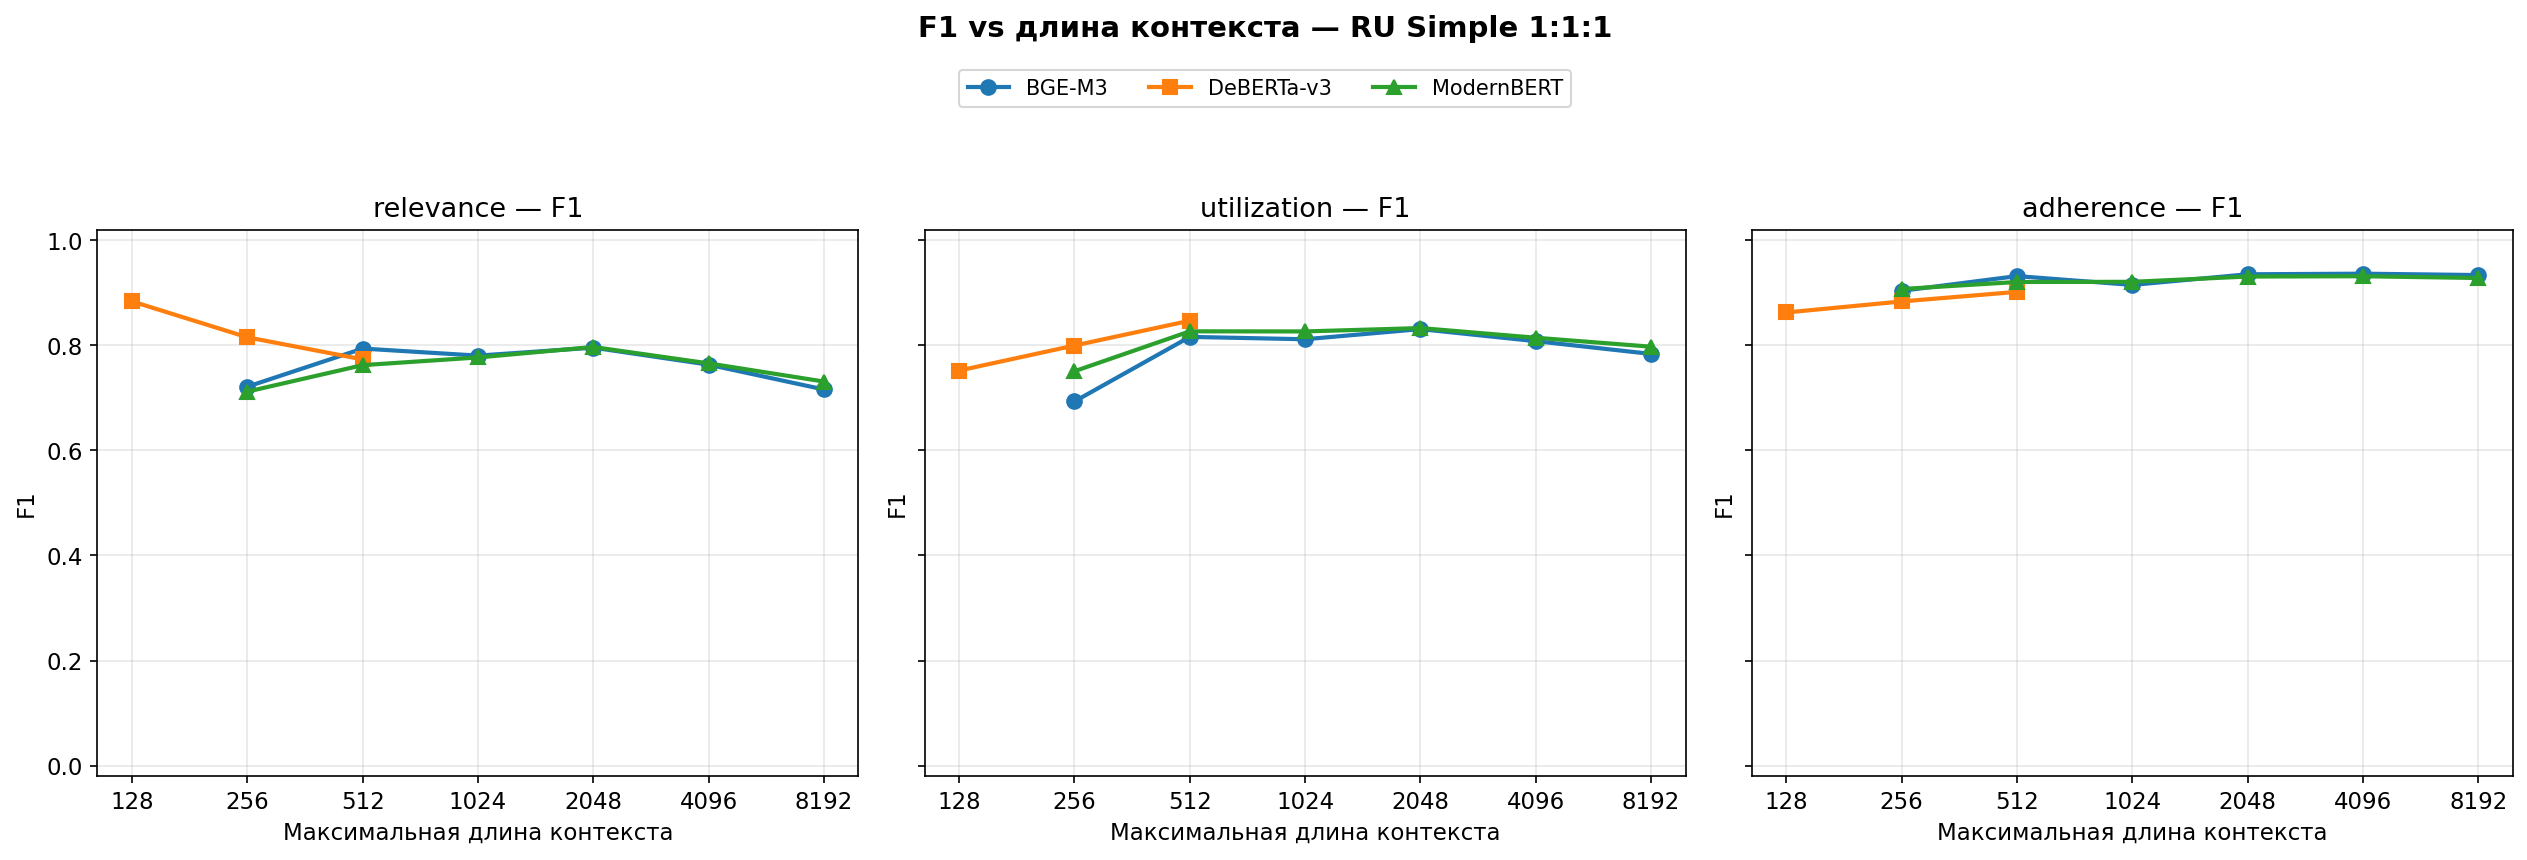

Saved: analysis_output/plots/f1_vs_length_RU_Simple_331.png


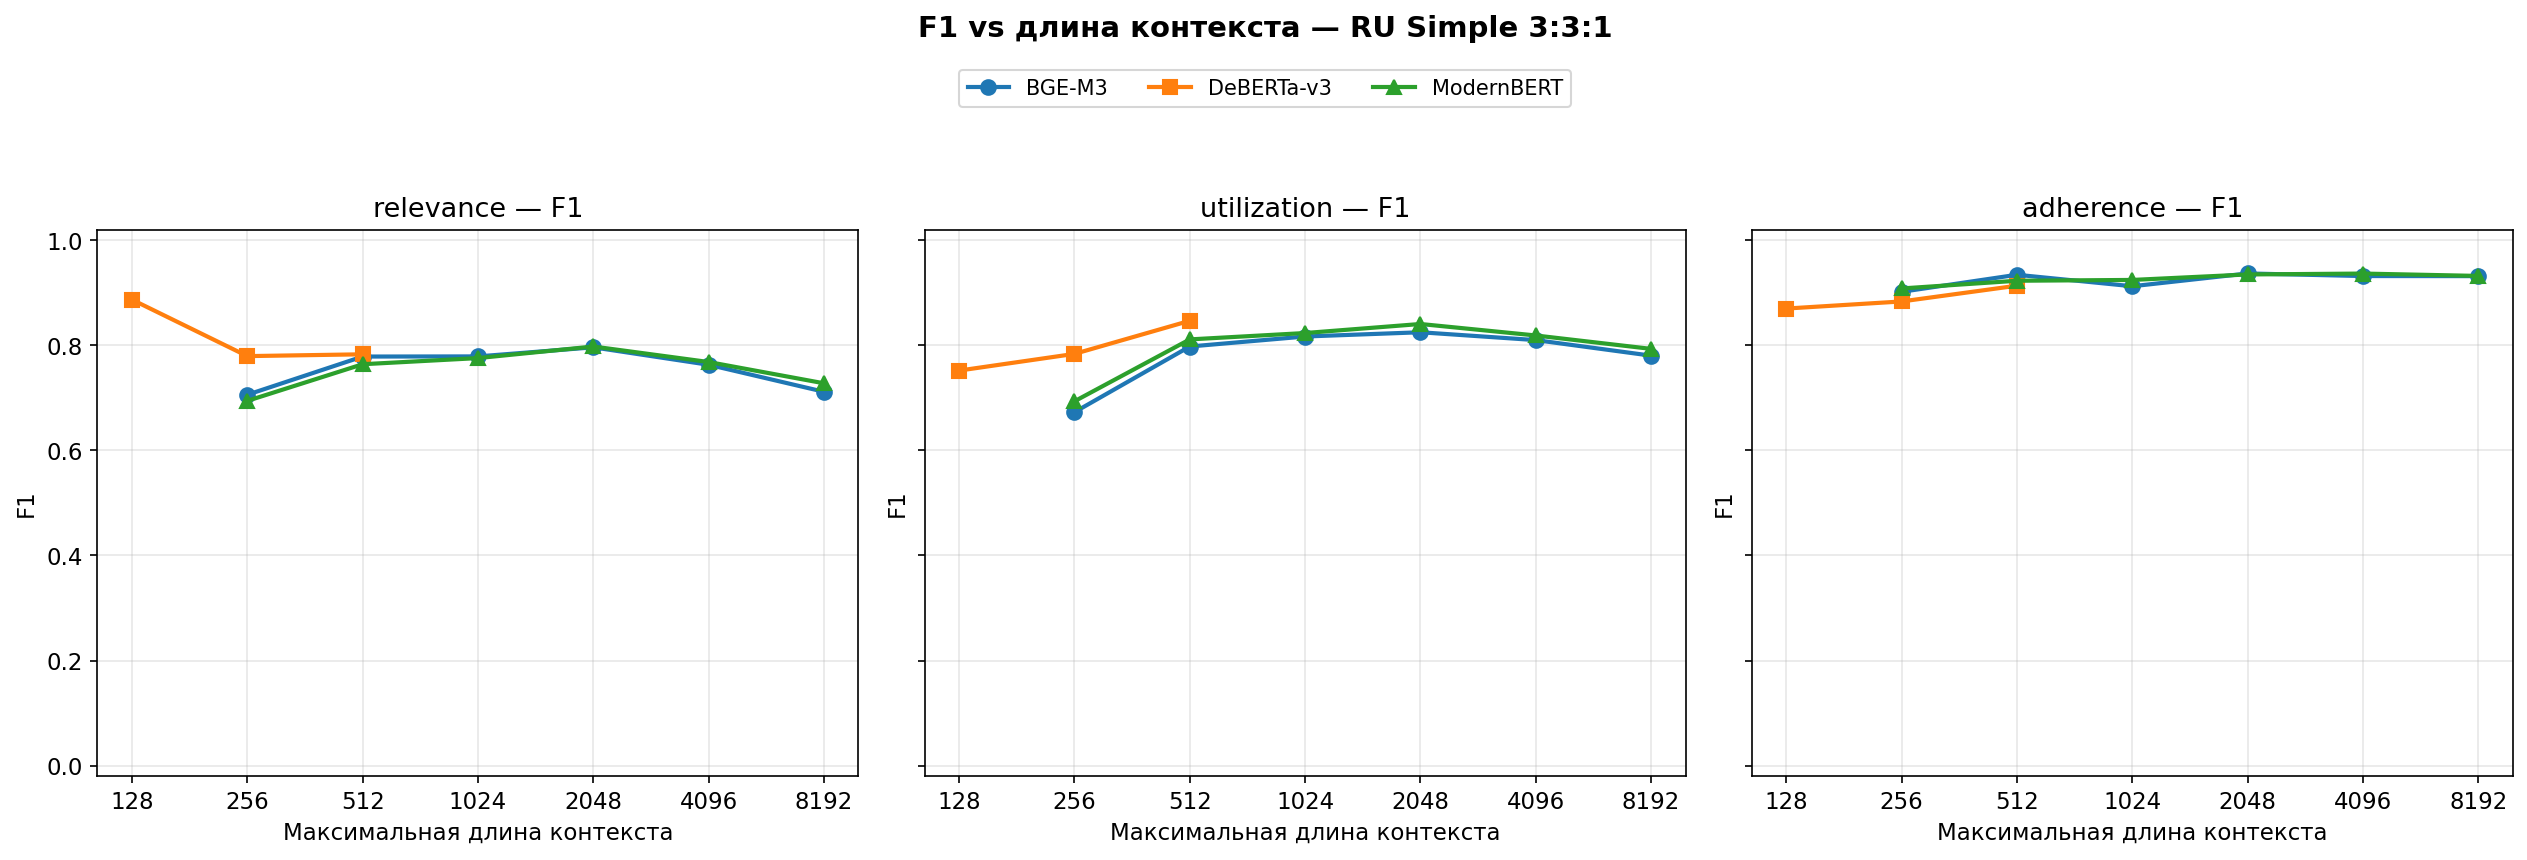

Saved: analysis_output/plots/f1_vs_length_EN_Simple_111.png


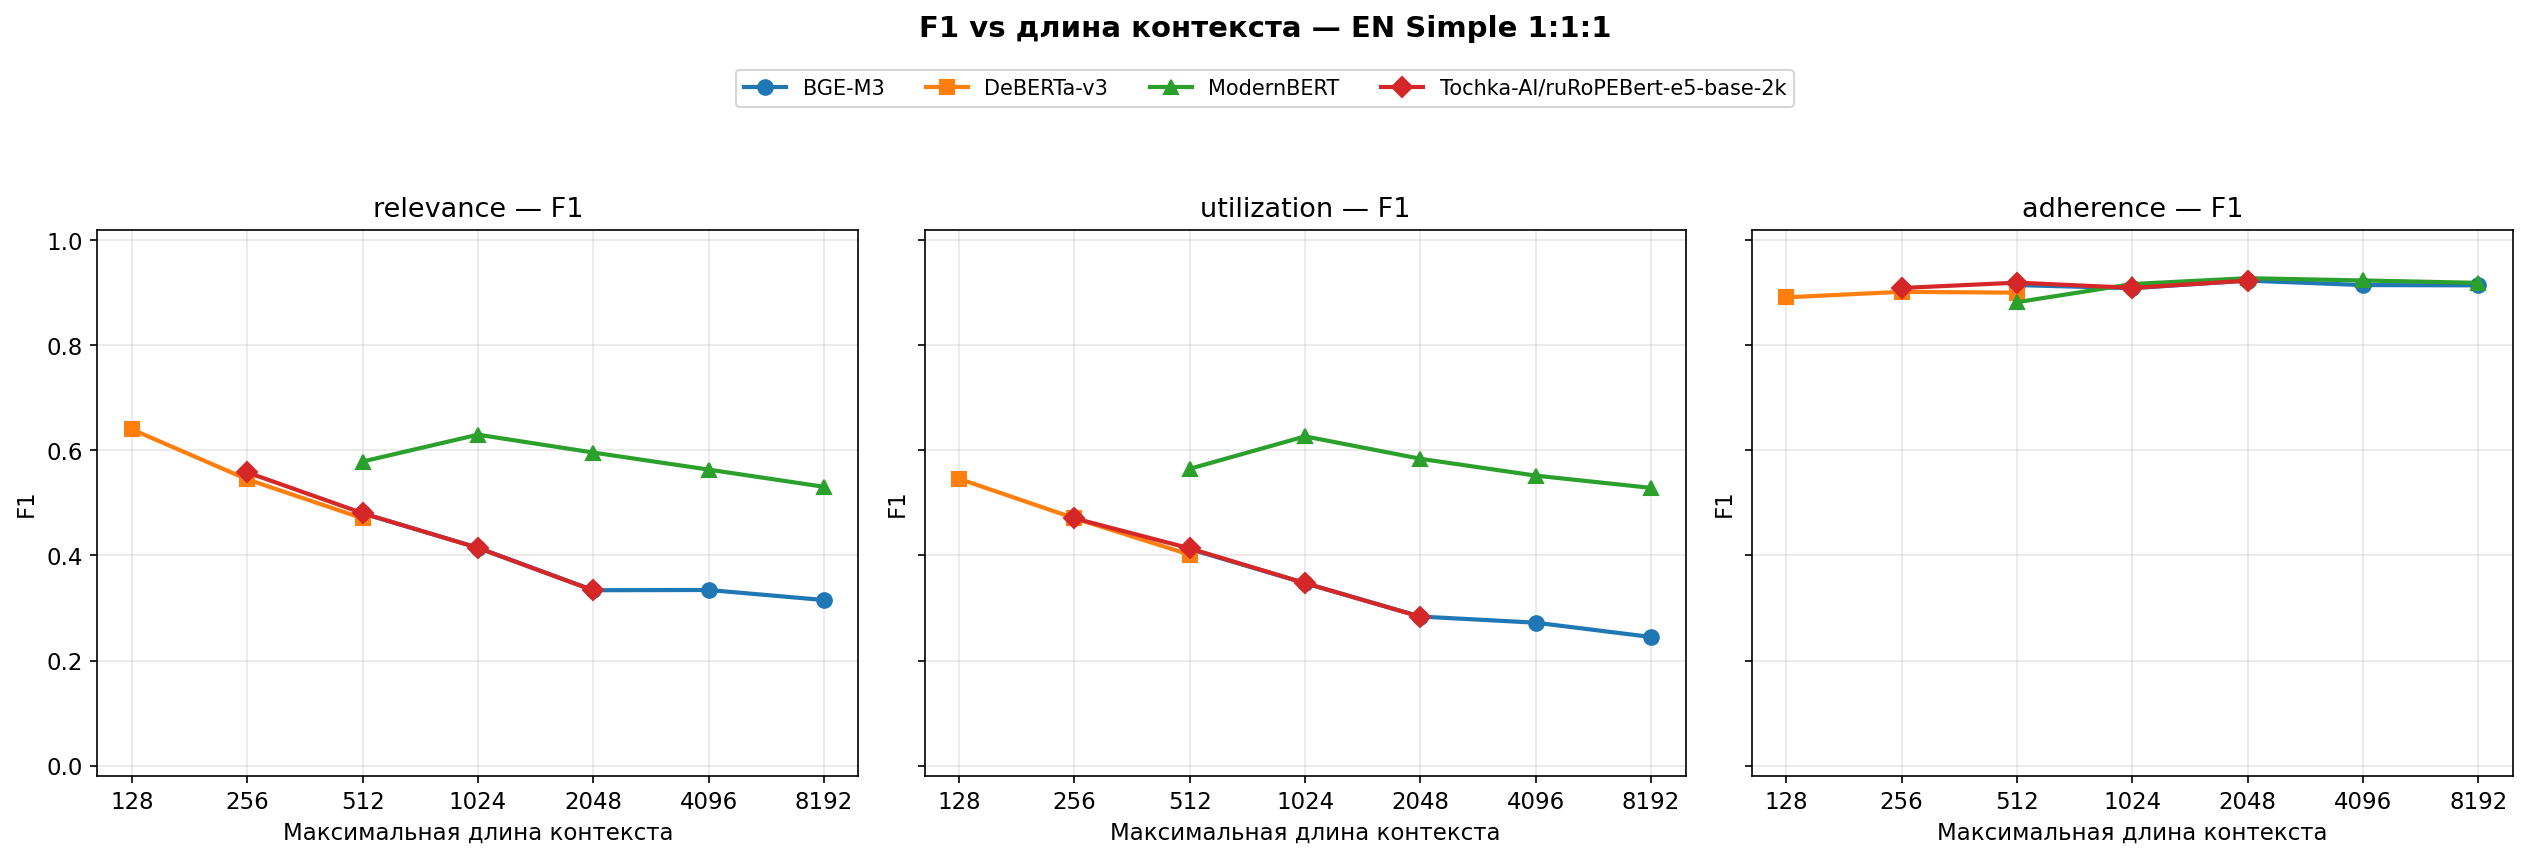

Saved: analysis_output/plots/f1_vs_length_EN_Simple_331.png


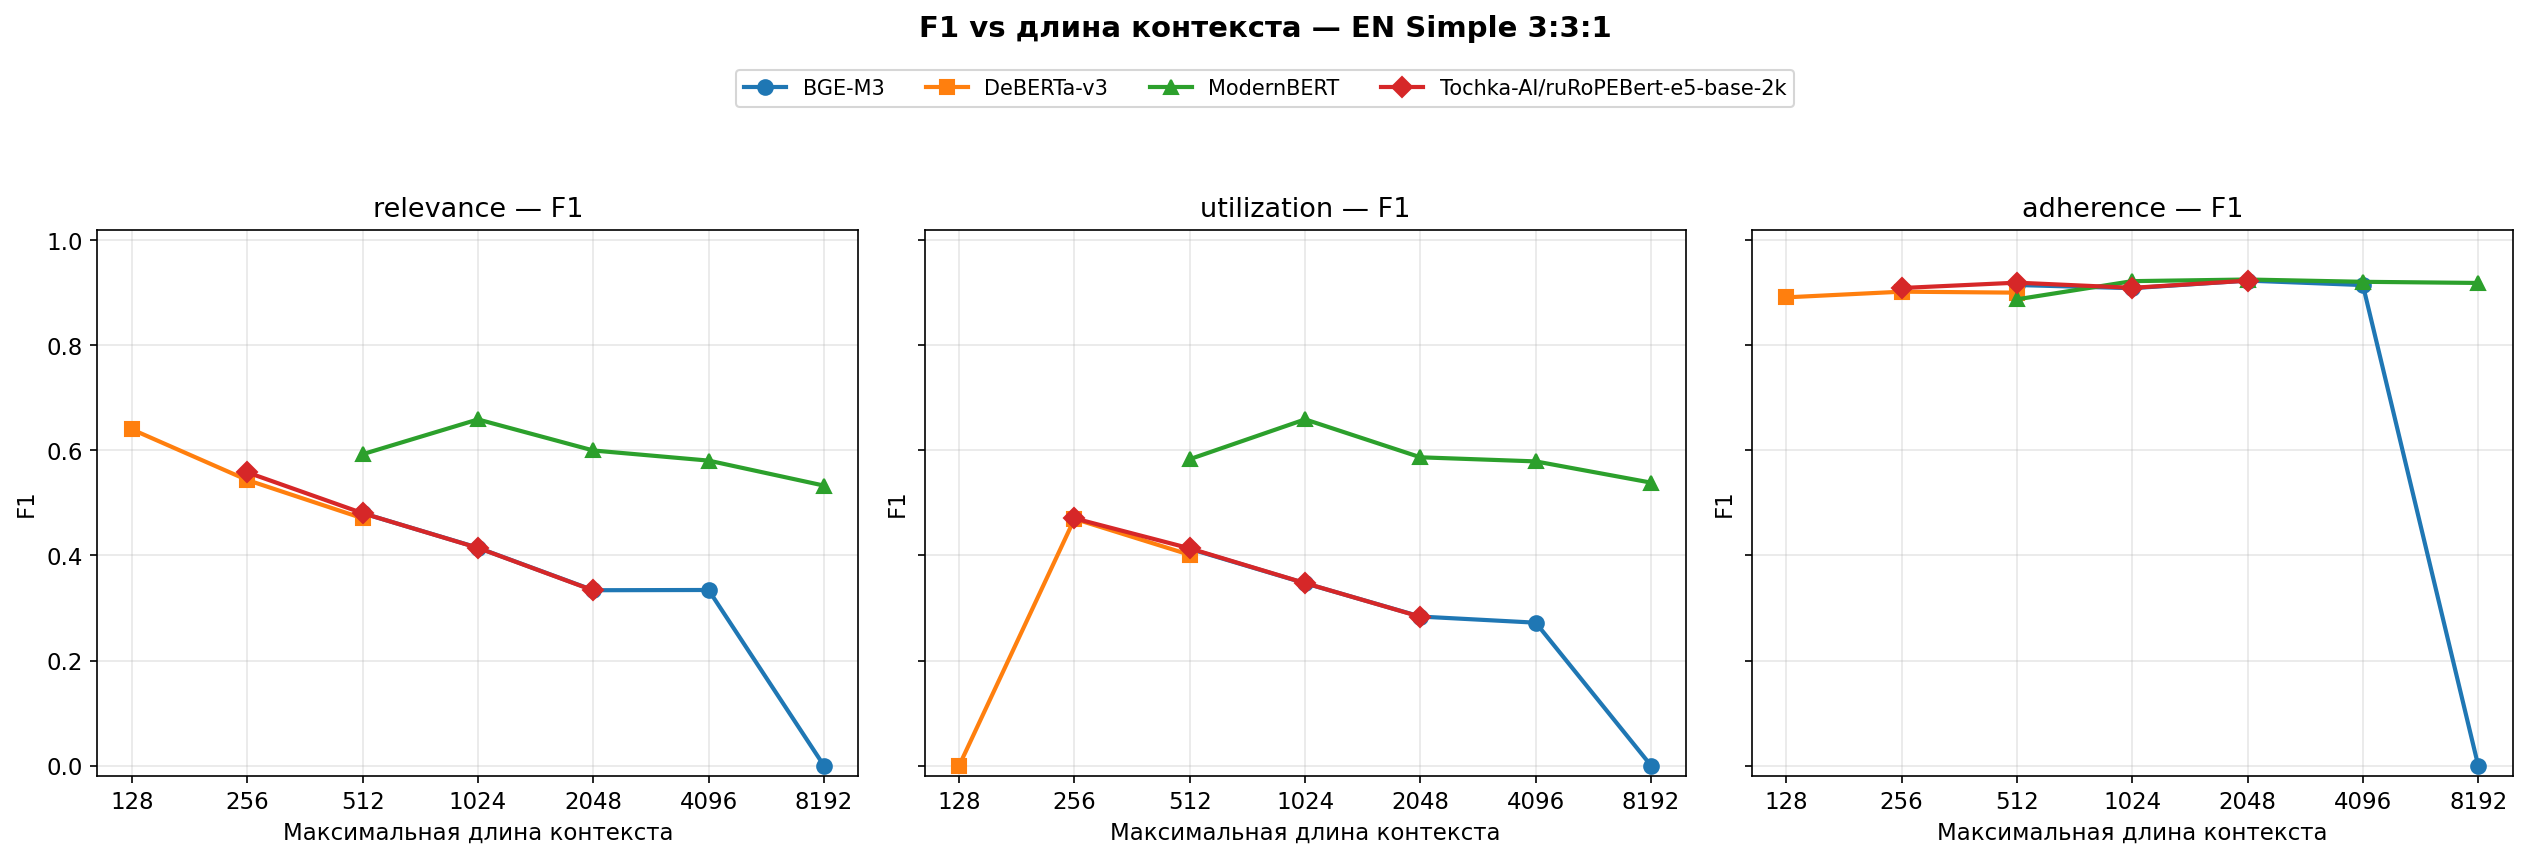

Saved: analysis_output/plots/f1_vs_length_RU_Complex_331.png


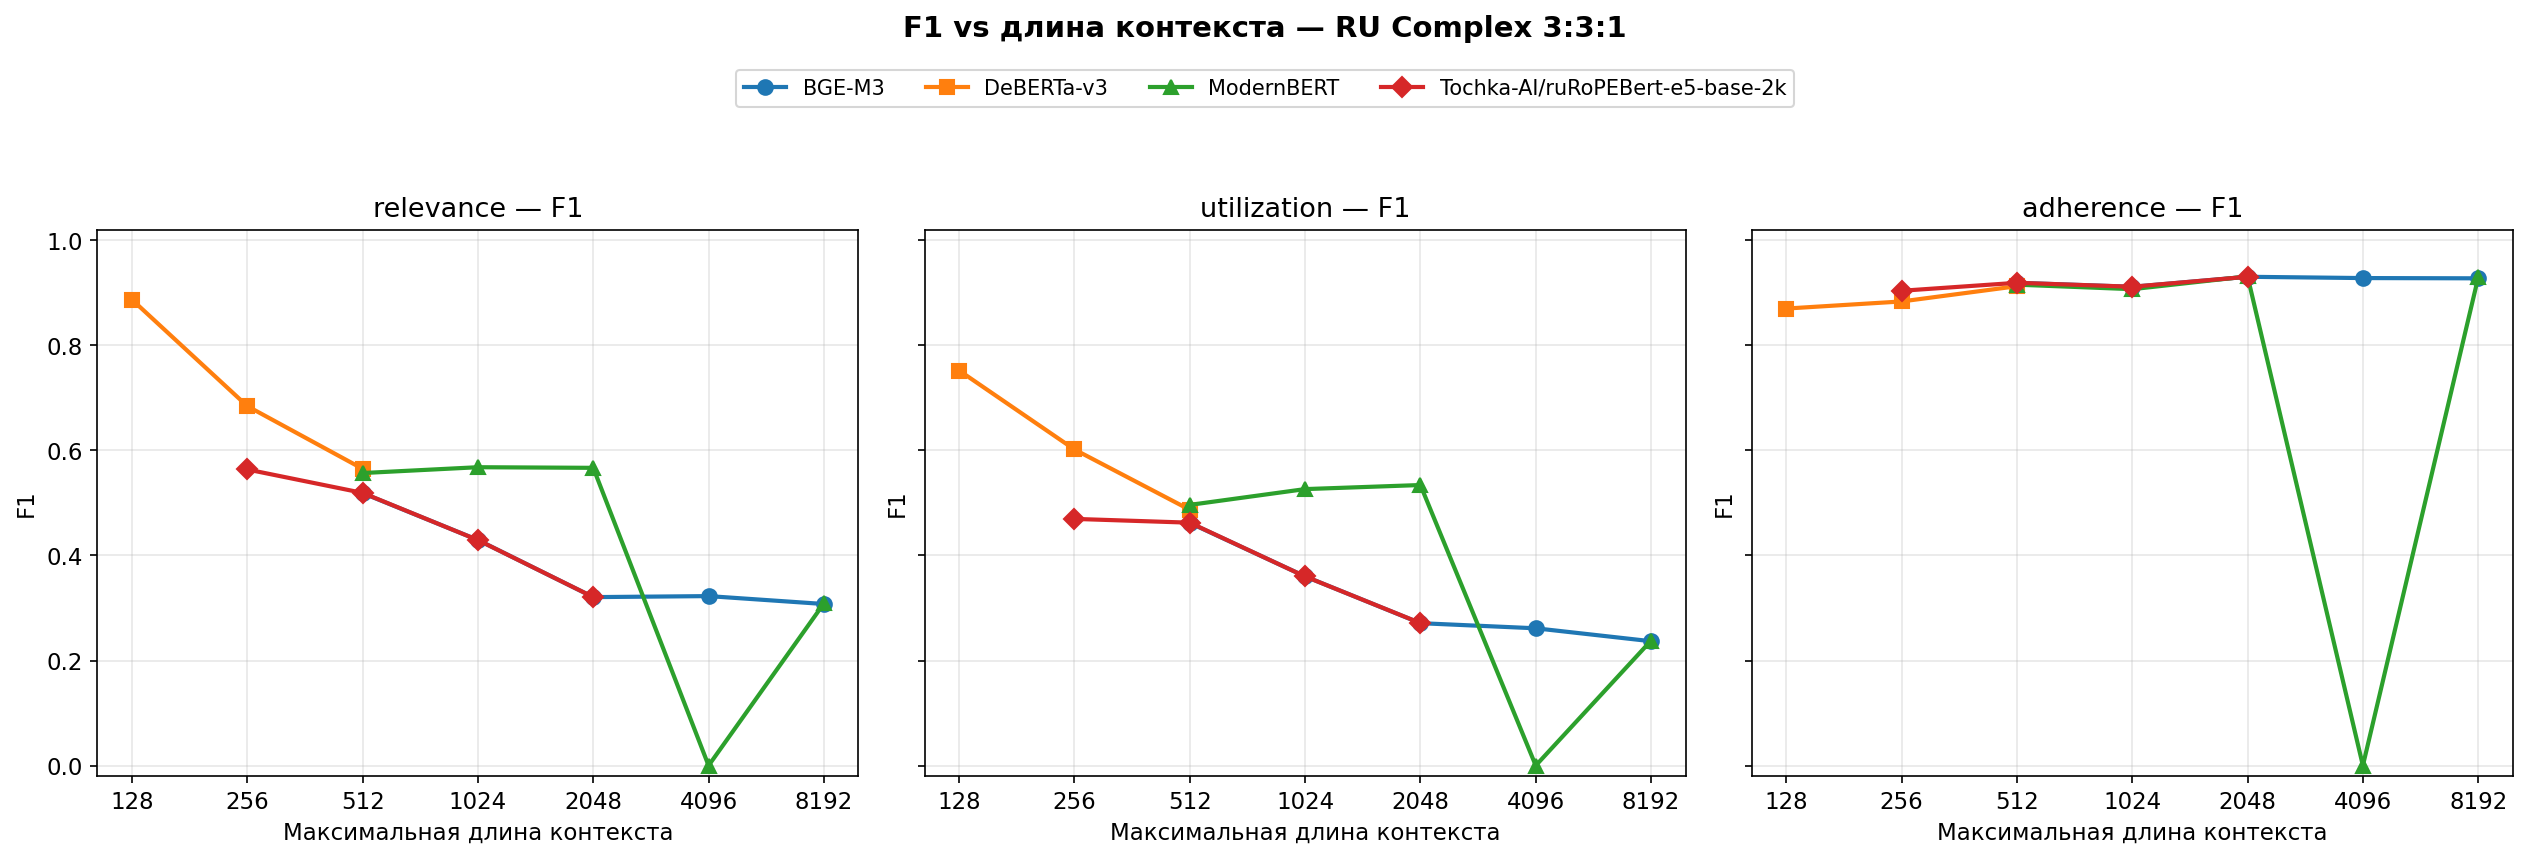

In [26]:
MARKERS = ["o", "s", "^", "D", "v", "P", "X"]
COLORS = plt.cm.tab10.colors

def plot_f1_vs_length(df, experiment_name, use_test=True, save=True):
    """1x3 subplots: relevance/utilization/adherence F1 vs max_length, по моделям."""
    fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
    sub = df[df["experiment"] == experiment_name].copy()

    for ax, target in zip(axes, TARGETS):
        col = f"test_{target}_f1" if use_test and f"test_{target}_f1" in sub.columns else f"{target}_f1"

        for i, (model, g) in enumerate(sub.groupby("model_short")):
            g = g.sort_values("max_length")
            ax.plot(
                g["max_length"], g[col],
                marker=MARKERS[i % len(MARKERS)],
                color=COLORS[i % len(COLORS)],
                label=model, linewidth=2, markersize=7,
            )

        ax.set_xlabel("Максимальная длина контекста")
        ax.set_ylabel("F1")
        ax.set_title(f"{TARGETS_RU[target]} — F1")
        ax.grid(True, alpha=0.3)
        ax.set_xscale("log", base=2)
        if len(sub):
            ax.set_xticks(sorted(sub["max_length"].unique()))
        ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
        ax.set_ylim(-0.02, 1.02)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.08), fontsize=10)
    fig.suptitle(f"F1 vs длина контекста — {experiment_name}", y=1.14, fontsize=14, fontweight="bold")
    fig.tight_layout()

    if save:
        fname = OUTPUT_DIR / "plots" / f"f1_vs_length_{experiment_name.replace(' ', '_').replace(':','')}.png"
        fig.savefig(fname, bbox_inches="tight")
        print(f"Saved: {fname}")
    plt.show()


for exp in [e for e in EXPERIMENTS.keys() if e in df_all["experiment"].unique()]:
    plot_f1_vs_length(df_all, exp)

## 5. Лучшие конфигурации моделей (Test F1 по 3 таргетам)

Saved: analysis_output/plots/best_models_bar_RU_Simple_111.png


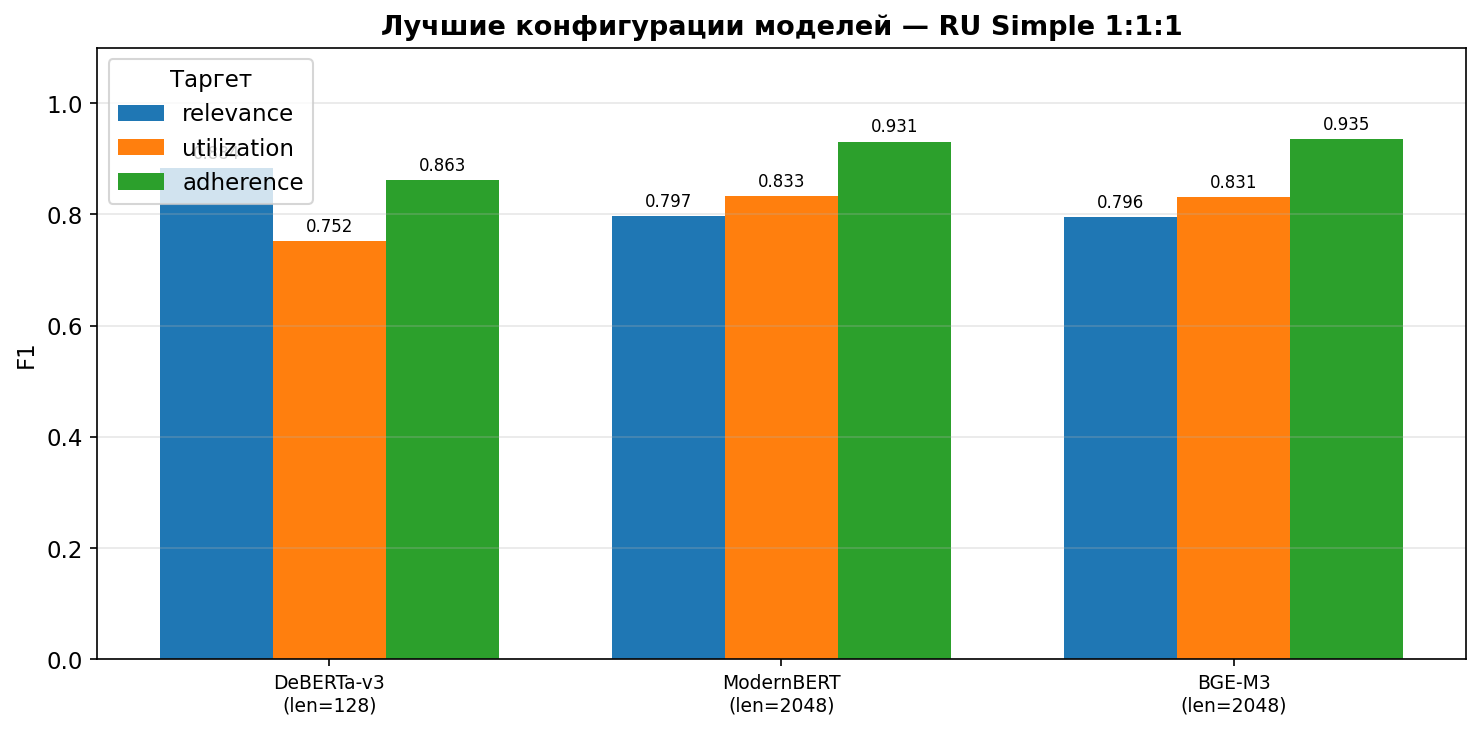

Saved: analysis_output/plots/best_models_bar_RU_Simple_331.png


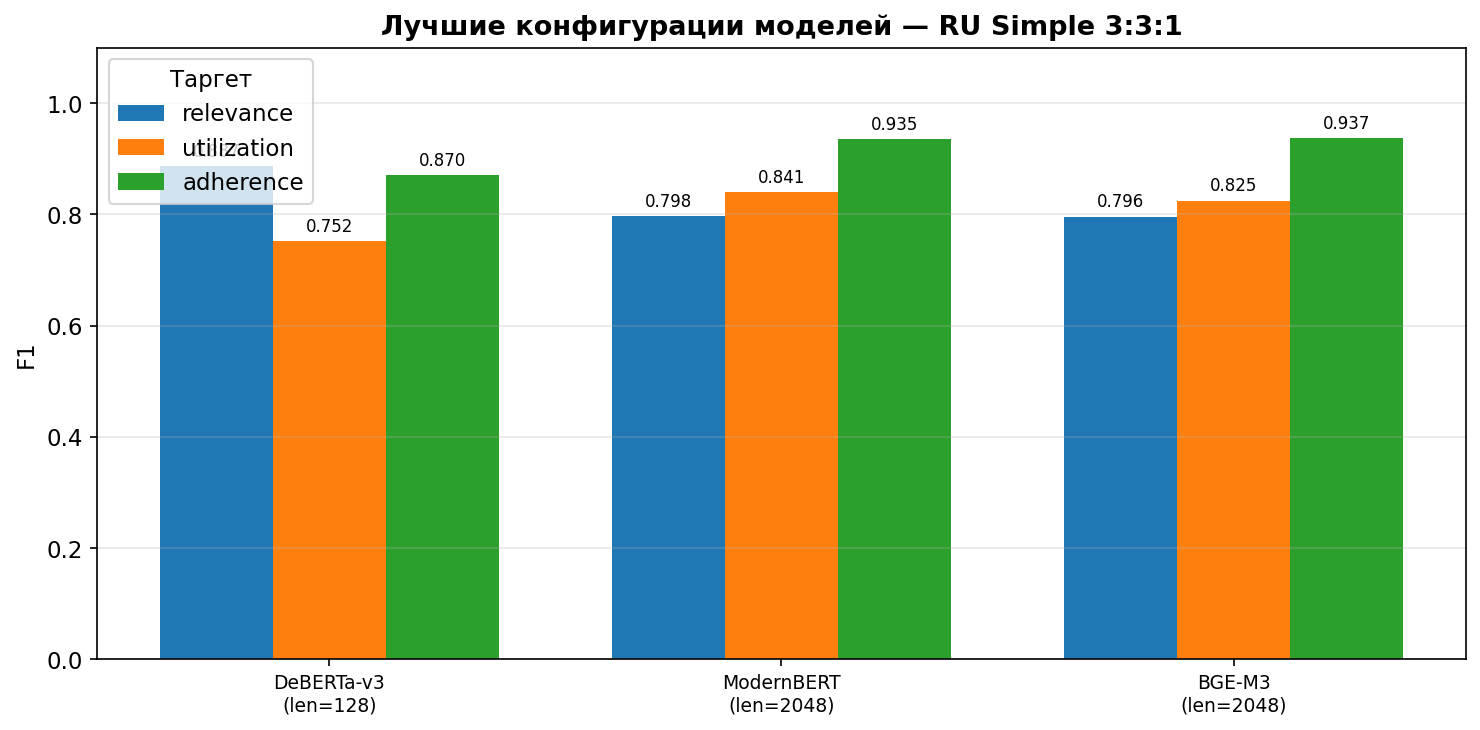

Saved: analysis_output/plots/best_models_bar_EN_Simple_111.png


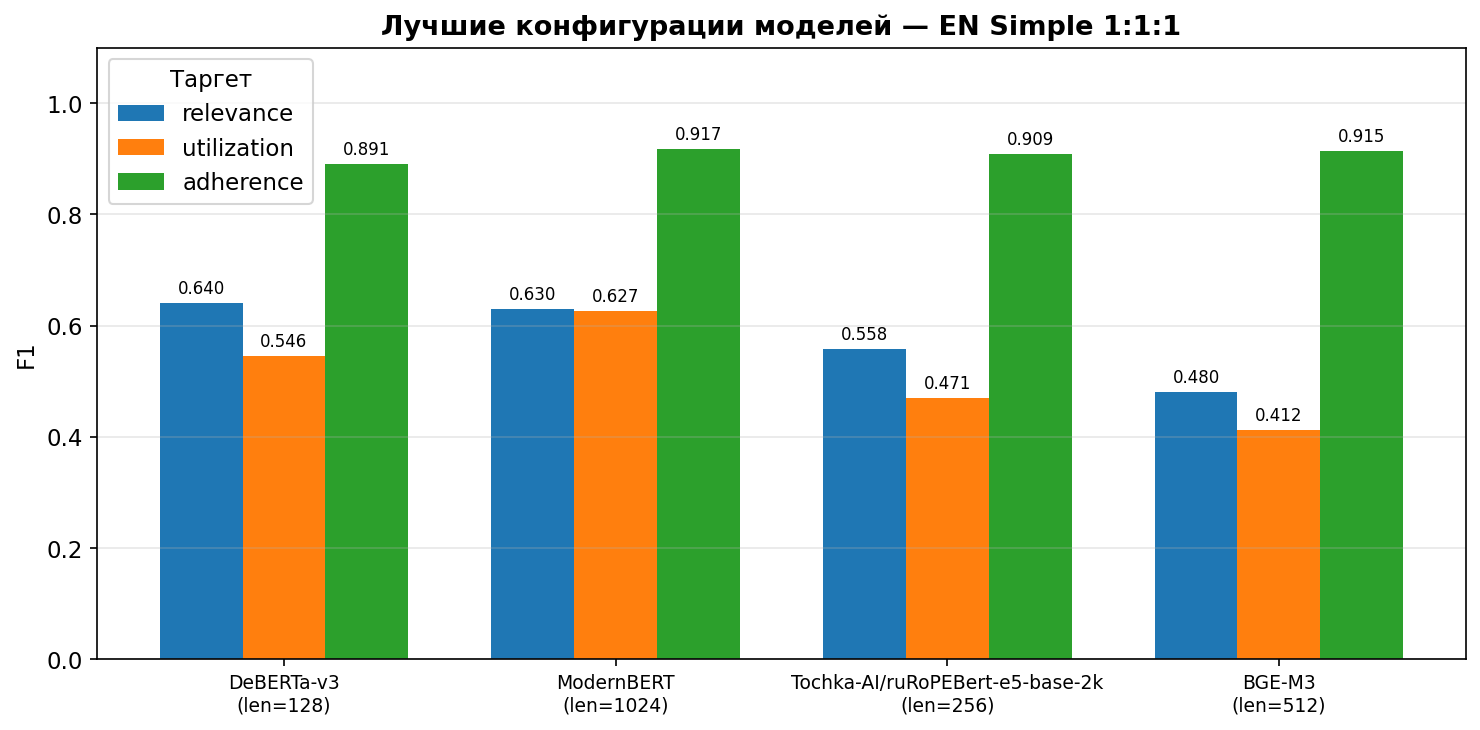

Saved: analysis_output/plots/best_models_bar_EN_Simple_331.png


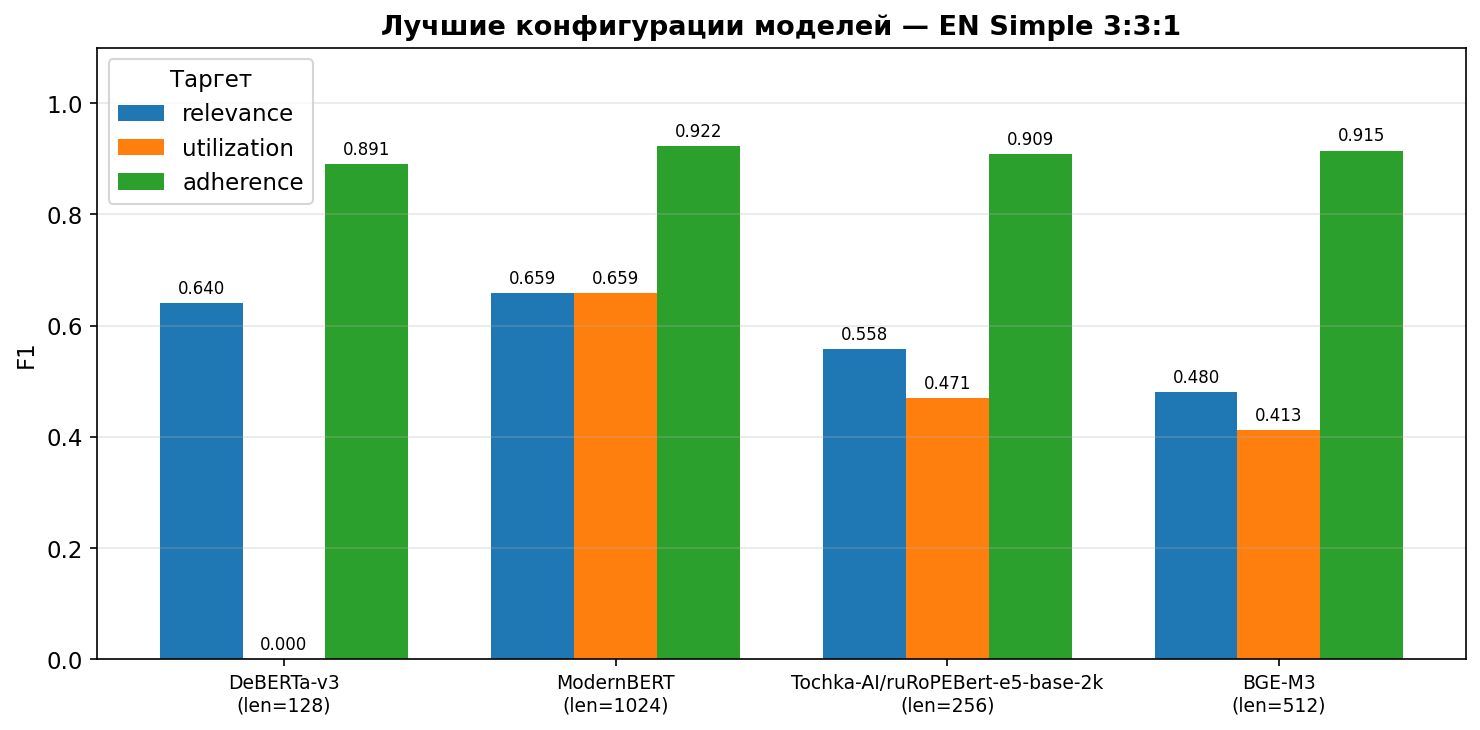

Saved: analysis_output/plots/best_models_bar_RU_Complex_331.png


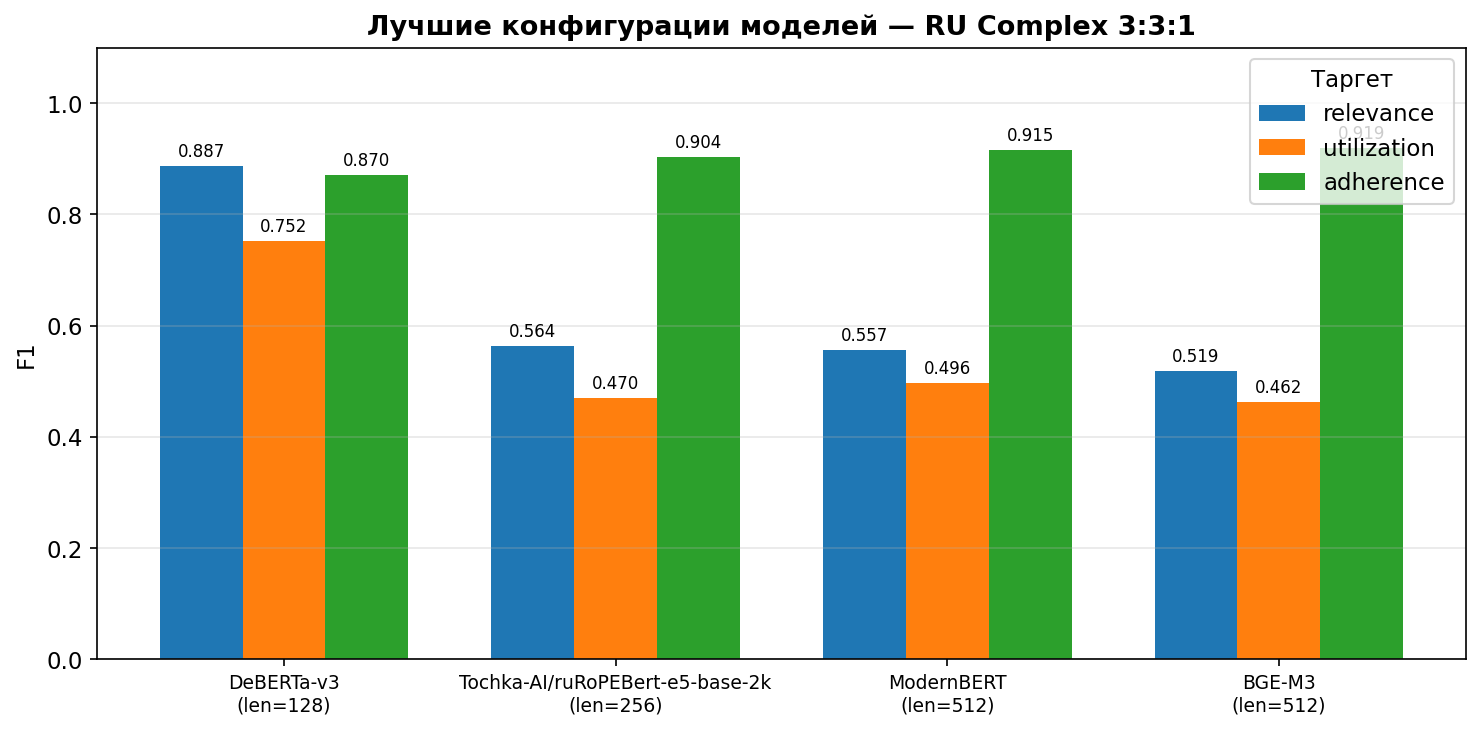

In [27]:
def plot_best_models_bar(df, experiment_name, use_test=True, save=True):
    """Grouped bar chart: лучшая конфигурация каждой модели, 3 таргета."""
    sub = df[df["experiment"] == experiment_name]
    if sub.empty:
        return
    idx_best = sub.groupby("model_short")["best_val_f1"].idxmax()
    best = sub.loc[idx_best].sort_values("best_val_f1", ascending=False)

    cols = [f"test_{t}_f1" if use_test and f"test_{t}_f1" in best.columns else f"{t}_f1" for t in TARGETS]

    x = np.arange(len(best))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (col, target) in enumerate(zip(cols, TARGETS)):
        vals = best[col].values
        bars = ax.bar(x + i * width, vals, width, label=TARGETS_RU[target])
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    labels = [f"{row['model_short']}\n(len={int(row['max_length'])})" for _, row in best.iterrows()]
    ax.set_xticks(x + width)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("F1")
    ax.set_ylim(0, 1.1)
    head = best["head_type"].iloc[0] if "head_type" in best.columns else ""
    ax.set_title(f"Лучшие конфигурации моделей — {experiment_name}", fontweight="bold")
    ax.legend(title="Таргет")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()

    if save:
        fname = OUTPUT_DIR / "plots" / f"best_models_bar_{experiment_name.replace(' ', '_').replace(':','')}.png"
        fig.savefig(fname, bbox_inches="tight")
        print(f"Saved: {fname}")
    plt.show()

for exp in [e for e in EXPERIMENTS.keys() if e in df_all["experiment"].unique()]:
    plot_best_models_bar(df_all, exp)

## 6. Ablation весов лосса: 1:1:1 vs 3:3:1 , простая модель


  Ablation весов: RU Simple 1:1:1 vs RU Simple 3:3:1
Средняя Δ по таргетам:
таргет
adherence      0.0022
relevance     -0.0050
utilization   -0.0083


/tmp/ipykernel_523/4235299302.py:45: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_delta.style


,модель,длина,таргет,F1 (RU Simple 1:1:1),F1 (RU Simple 3:3:1),Δ (3:3:1 − 1:1:1)
0,BGE-M3,1024,relevance,0.7804,0.7789,-0.0015
1,BGE-M3,2048,relevance,0.7956,0.7962,0.0006
2,BGE-M3,256,relevance,0.7212,0.7059,-0.0153
3,BGE-M3,4096,relevance,0.7632,0.7630,-0.0002
4,BGE-M3,512,relevance,0.7938,0.7786,-0.0152
5,BGE-M3,8192,relevance,0.7159,0.7116,-0.0043
6,DeBERTa-v3,128,relevance,0.8837,0.8869,0.0032
7,DeBERTa-v3,256,relevance,0.8152,0.7794,-0.0358
8,DeBERTa-v3,512,relevance,0.7732,0.7829,0.0097
9,ModernBERT,1024,relevance,0.7769,0.7757,-0.0012


Saved: analysis_output/plots/ablation_weights_RU_Simple_111_vs_RU_Simple_331.png


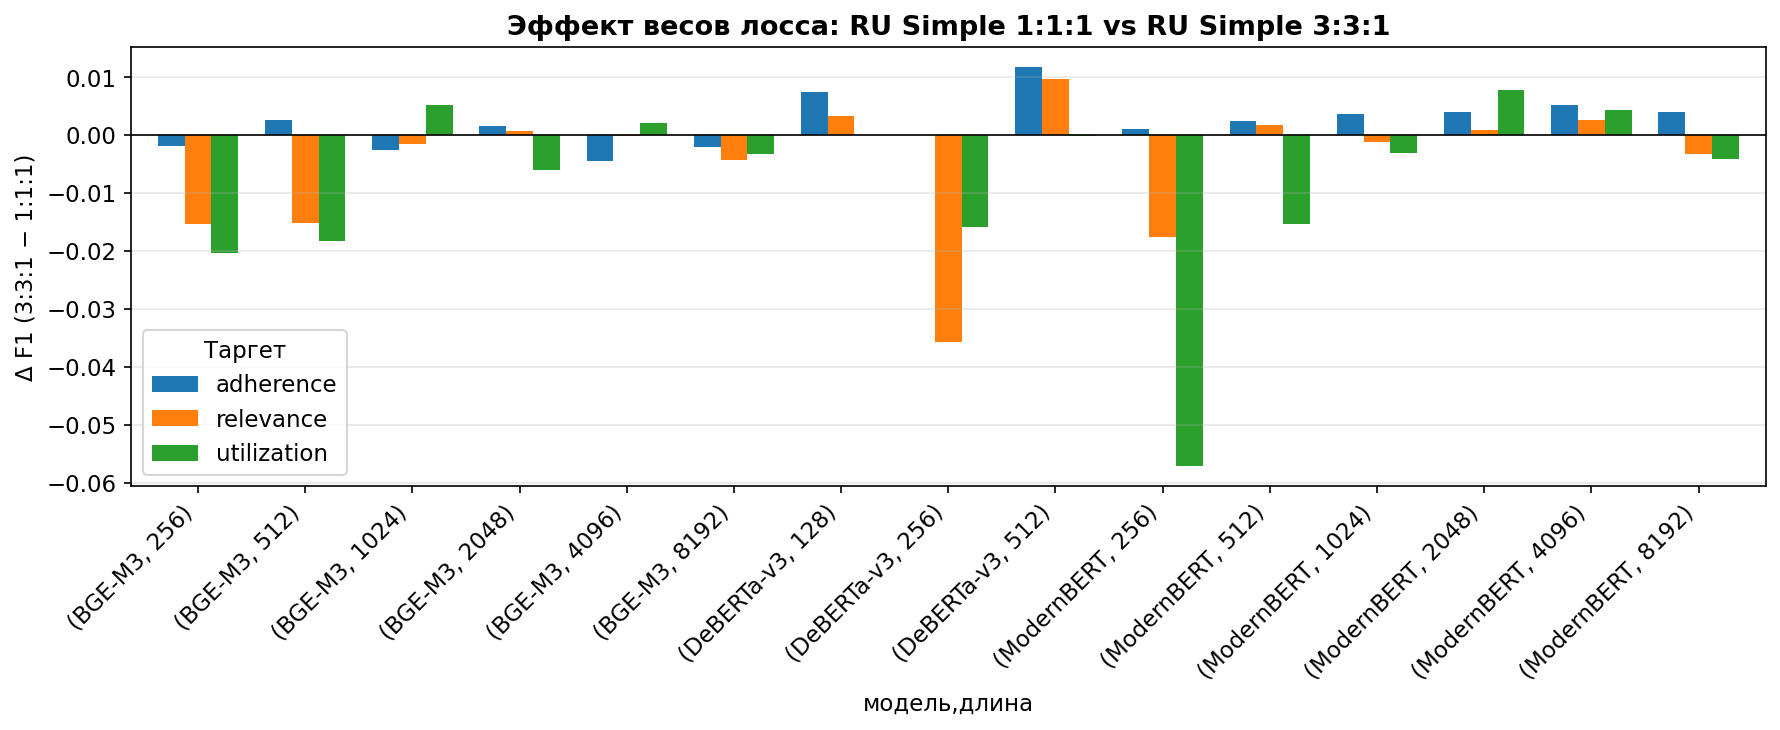


  Ablation весов: EN Simple 1:1:1 vs EN Simple 3:3:1
Средняя Δ по таргетам:
таргет
adherence     -0.0534
relevance     -0.0147
utilization   -0.0412


/tmp/ipykernel_523/4235299302.py:45: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_delta.style


,модель,длина,таргет,F1 (EN Simple 1:1:1),F1 (EN Simple 3:3:1),Δ (3:3:1 − 1:1:1)
0,BGE-M3,1024,relevance,0.4146,0.4146,0.0000
1,BGE-M3,2048,relevance,0.3338,0.3338,0.0000
2,BGE-M3,4096,relevance,0.3342,0.3342,0.0000
3,BGE-M3,512,relevance,0.4801,0.4804,0.0004
4,BGE-M3,8192,relevance,0.3151,0.0000,-0.3151
5,DeBERTa-v3,128,relevance,0.6399,0.6399,-0.0000
6,DeBERTa-v3,256,relevance,0.5448,0.5435,-0.0013
7,DeBERTa-v3,512,relevance,0.4707,0.4707,0.0001
8,Tochka-AI/ruRoPEBert-e5-base-2k,1024,relevance,0.4144,0.4144,0.0000
9,Tochka-AI/ruRoPEBert-e5-base-2k,2048,relevance,0.3334,0.3334,0.0000


Saved: analysis_output/plots/ablation_weights_EN_Simple_111_vs_EN_Simple_331.png


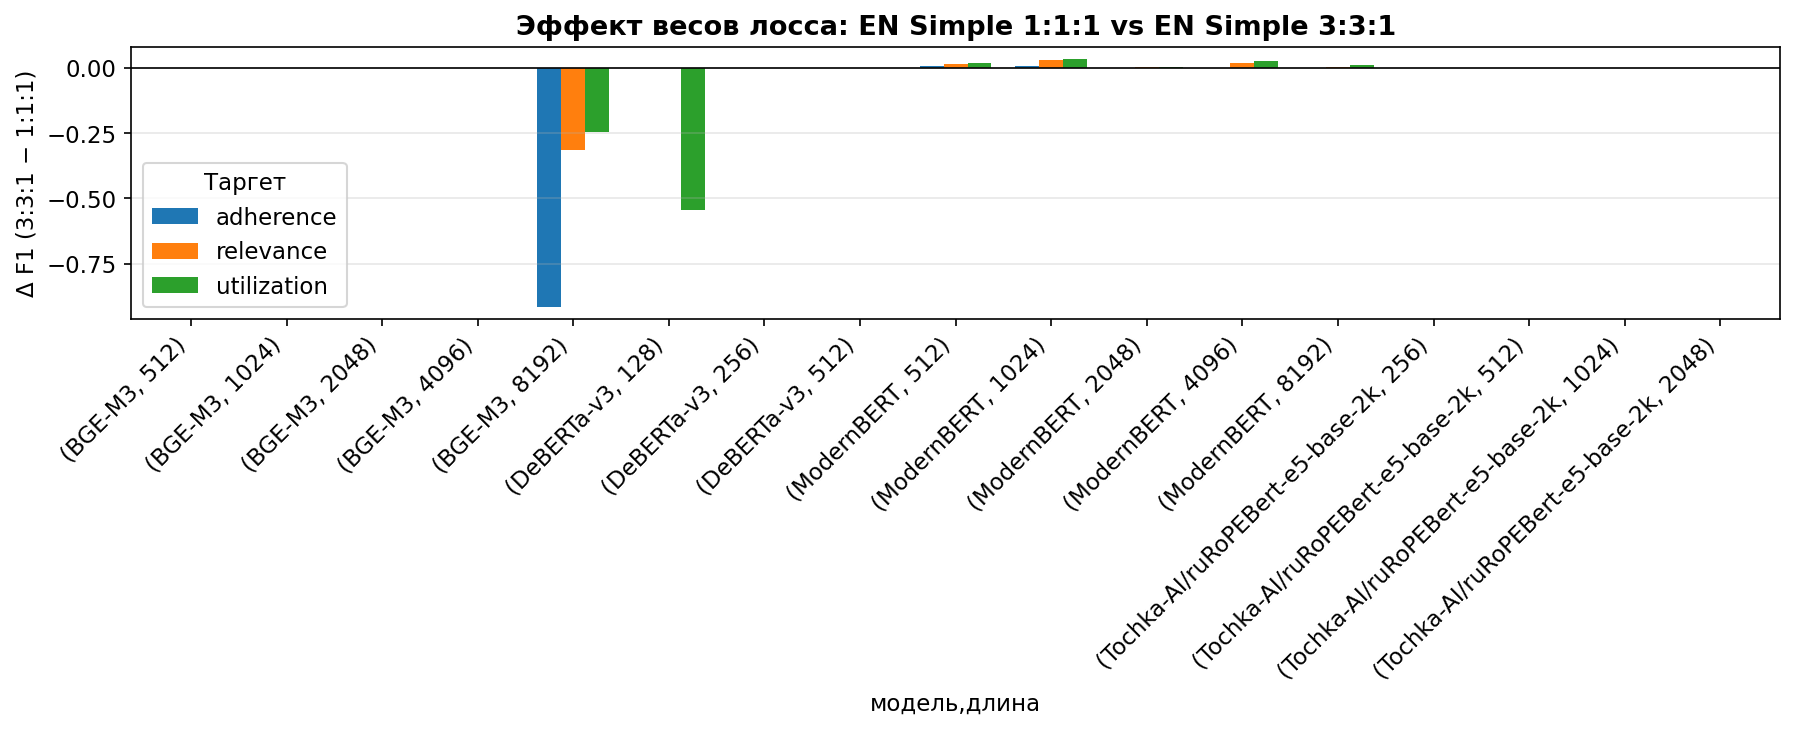

In [28]:

WEIGHT_PAIRS = [
    ("RU Simple 1:1:1", "RU Simple 3:3:1"),
    ("EN Simple 1:1:1", "EN Simple 3:3:1"),
]

df_simple = df_all[df_all["head_type"] == "Simple"]

for exp_a, exp_b in WEIGHT_PAIRS:
    if exp_a not in df_simple["experiment"].values or exp_b not in df_simple["experiment"].values:
        print(f"[!] Пропускаю пару ({exp_a}, {exp_b}) — нет данных")
        continue

    da = df_simple[df_simple["experiment"] == exp_a].set_index(["model_short", "max_length"])
    db = df_simple[df_simple["experiment"] == exp_b].set_index(["model_short", "max_length"])

    common_idx = da.index.intersection(db.index)
    if common_idx.empty:
        print(f"[!] Нет общих (модель, длина) для {exp_a} и {exp_b}")
        continue

    rows = []
    for target in TARGETS:
        col = f"test_{target}_f1" if f"test_{target}_f1" in da.columns else f"{target}_f1"
        for idx in common_idx:
            va = da.loc[idx, col]
            vb = db.loc[idx, col]
            if isinstance(va, pd.Series): va = va.iloc[0]
            if isinstance(vb, pd.Series): vb = vb.iloc[0]
            rows.append({
                "модель": idx[0],
                "длина": idx[1],
                "таргет": TARGETS_RU[target],
                f"F1 ({exp_a})": va,
                f"F1 ({exp_b})": vb,
                "Δ (3:3:1 − 1:1:1)": vb - va,
            })

    df_delta = pd.DataFrame(rows)
    print(f"\n{'='*70}")
    print(f"  Ablation весов: {exp_a} vs {exp_b}")
    print(f"{'='*70}")
    print("Средняя Δ по таргетам:")
    print(df_delta.groupby("таргет")["Δ (3:3:1 − 1:1:1)"].mean().round(4).to_string())
    display(
        df_delta.style
        .format("{:.4f}", subset=[c for c in df_delta.columns if c not in ["модель", "длина", "таргет"]])
        .applymap(
            lambda v: "color: green" if isinstance(v, float) and v > 0.005
                      else ("color: red" if isinstance(v, float) and v < -0.005 else ""),
            subset=["Δ (3:3:1 − 1:1:1)"]
        )
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    pivot_delta = df_delta.pivot_table(
        index=["модель", "длина"], columns="таргет", values="Δ (3:3:1 − 1:1:1)"
    )
    pivot_delta.plot(kind="bar", ax=ax, width=0.75)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Δ F1 (3:3:1 − 1:1:1)")
    ax.set_title(f"Эффект весов лосса: {exp_a} vs {exp_b}", fontweight="bold")
    ax.legend(title="Таргет")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    fig.tight_layout()

    tag = exp_a.replace(' ','_').replace(':','') + "_vs_" + exp_b.replace(' ','_').replace(':','')
    fname = OUTPUT_DIR / "plots" / f"ablation_weights_{tag}.png"
    fig.savefig(fname, bbox_inches="tight")
    print(f"Saved: {fname}")
    plt.show()

    df_delta.to_csv(OUTPUT_DIR / "tables" / f"ablation_weights_{tag}.csv", index=False)

## 7. RU vs EN, простая модель


  RU vs EN (веса 1:1:1)
Средняя Δ (RU − EN) по таргетам:
таргет
adherence      0.0072
relevance      0.2863
utilization    0.3625


/tmp/ipykernel_523/3223374665.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_lang.style


,модель,длина,таргет,F1 (RU),F1 (EN),Δ (RU − EN)
0,BGE-M3,1024,relevance,0.7804,0.4146,0.3658
1,BGE-M3,2048,relevance,0.7956,0.3338,0.4618
2,BGE-M3,4096,relevance,0.7632,0.3342,0.4289
3,BGE-M3,512,relevance,0.7938,0.4801,0.3137
4,BGE-M3,8192,relevance,0.7159,0.3151,0.4008
5,DeBERTa-v3,128,relevance,0.8837,0.6399,0.2438
6,DeBERTa-v3,256,relevance,0.8152,0.5448,0.2704
7,DeBERTa-v3,512,relevance,0.7732,0.4707,0.3025
8,ModernBERT,1024,relevance,0.7769,0.6299,0.1470
9,ModernBERT,2048,relevance,0.7968,0.5959,0.2009


Saved: analysis_output/plots/ru_vs_en_111.png


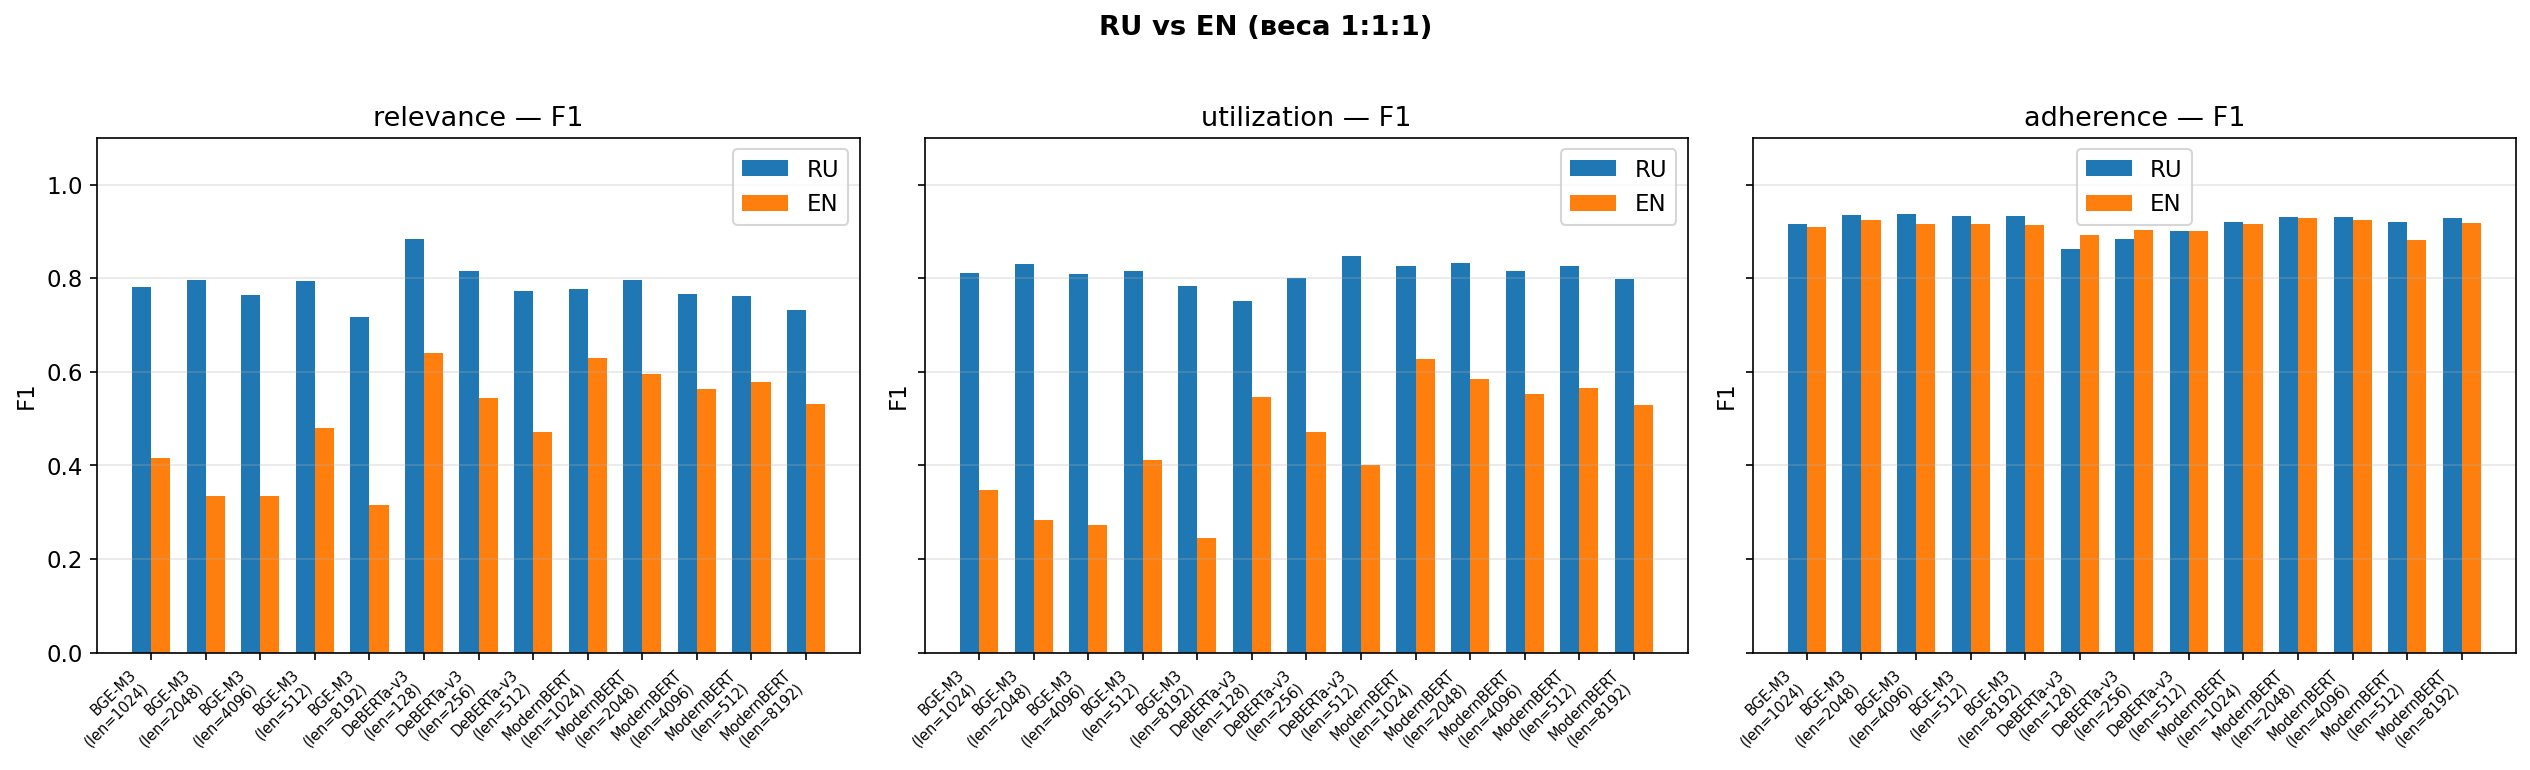


  RU vs EN (веса 3:3:1)
Средняя Δ (RU − EN) по таргетам:
таргет
adherence      0.0796
relevance      0.3022
utilization    0.4128


/tmp/ipykernel_523/3223374665.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_lang.style


,модель,длина,таргет,F1 (RU),F1 (EN),Δ (RU − EN)
0,BGE-M3,1024,relevance,0.7789,0.4146,0.3643
1,BGE-M3,2048,relevance,0.7962,0.3338,0.4624
2,BGE-M3,4096,relevance,0.7630,0.3342,0.4287
3,BGE-M3,512,relevance,0.7786,0.4804,0.2982
4,BGE-M3,8192,relevance,0.7116,0.0000,0.7116
5,DeBERTa-v3,128,relevance,0.8869,0.6399,0.2470
6,DeBERTa-v3,256,relevance,0.7794,0.5435,0.2359
7,DeBERTa-v3,512,relevance,0.7829,0.4707,0.3122
8,ModernBERT,1024,relevance,0.7757,0.6589,0.1168
9,ModernBERT,2048,relevance,0.7978,0.5998,0.1979


Saved: analysis_output/plots/ru_vs_en_331.png


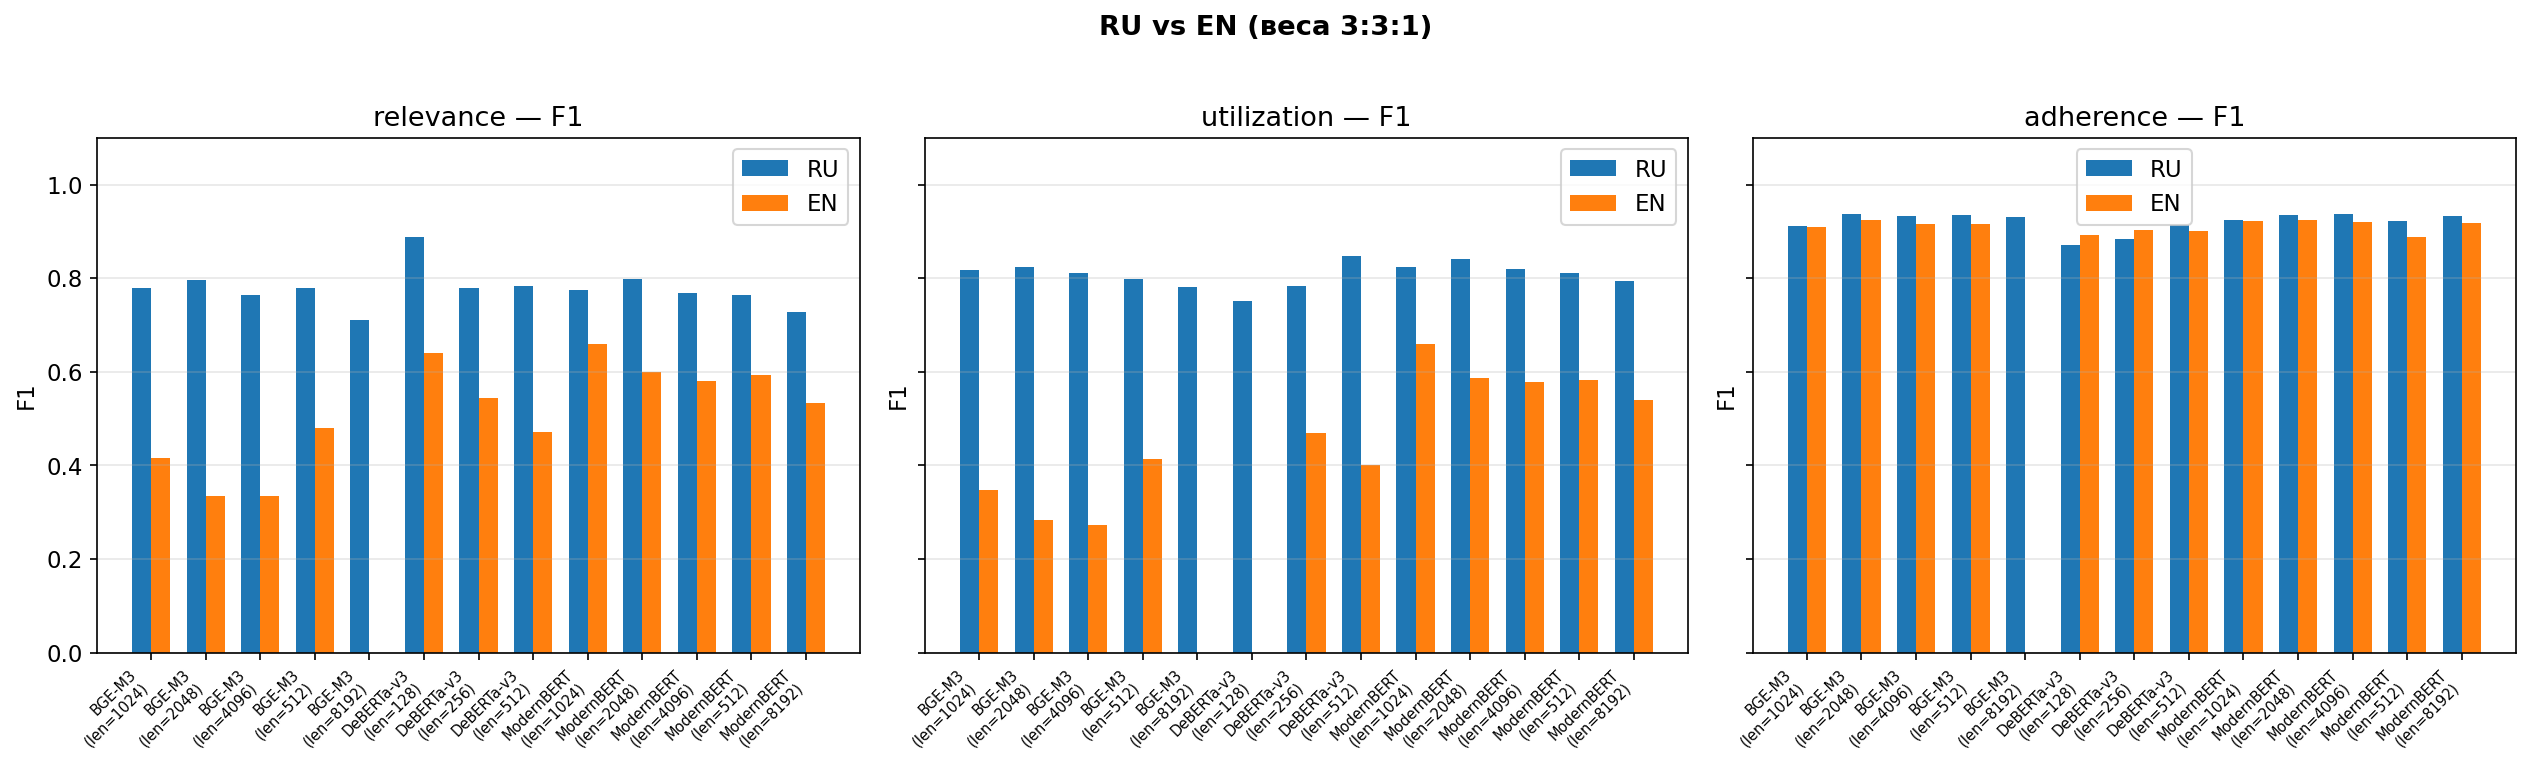

In [29]:

LANG_PAIRS = [
    ("RU Simple 1:1:1", "EN Simple 1:1:1"),
    ("RU Simple 3:3:1", "EN Simple 3:3:1"),
]

df_simple = df_all[df_all["head_type"] == "Simple"]

for exp_ru, exp_en in LANG_PAIRS:
    if exp_ru not in df_simple["experiment"].values or exp_en not in df_simple["experiment"].values:
        print(f"[!] Пропускаю пару ({exp_ru}, {exp_en}) — нет данных")
        continue

    d_ru = df_simple[df_simple["experiment"] == exp_ru].set_index(["model_short", "max_length"])
    d_en = df_simple[df_simple["experiment"] == exp_en].set_index(["model_short", "max_length"])

    common_idx = d_ru.index.intersection(d_en.index)
    if common_idx.empty:
        print(f"[!] Нет общих (модель, длина) для {exp_ru} и {exp_en}")
        continue

    rows = []
    for target in TARGETS:
        col = f"test_{target}_f1" if f"test_{target}_f1" in d_ru.columns else f"{target}_f1"
        for idx in common_idx:
            v_ru = d_ru.loc[idx, col]
            v_en = d_en.loc[idx, col]
            if isinstance(v_ru, pd.Series): v_ru = v_ru.iloc[0]
            if isinstance(v_en, pd.Series): v_en = v_en.iloc[0]
            rows.append({
                "модель": idx[0],
                "длина": idx[1],
                "таргет": TARGETS_RU[target],
                "F1 (RU)": v_ru,
                "F1 (EN)": v_en,
                "Δ (RU − EN)": v_ru - v_en,
            })

    df_lang = pd.DataFrame(rows)
    weights_label = exp_ru.split()[-1]

    print(f"\n{'='*70}")
    print(f"  RU vs EN (веса {weights_label})")
    print(f"{'='*70}")
    print("Средняя Δ (RU − EN) по таргетам:")
    print(df_lang.groupby("таргет")["Δ (RU − EN)"].mean().round(4).to_string())
    display(
        df_lang.style
        .format("{:.4f}", subset=[c for c in df_lang.columns if c not in ["модель", "длина", "таргет"]])
        .applymap(
            lambda v: "color: green" if isinstance(v, float) and v > 0.005
                      else ("color: red" if isinstance(v, float) and v < -0.005 else ""),
            subset=["Δ (RU − EN)"]
        )
    )

    fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
    for ax, target in zip(axes, TARGETS):
        sub = df_lang[df_lang["таргет"] == TARGETS_RU[target]].copy()
        sub["label"] = sub["модель"] + "\n(len=" + sub["длина"].astype(str) + ")"

        x = np.arange(len(sub))
        w = 0.35
        ax.bar(x - w/2, sub["F1 (RU)"], w, label="RU", color=COLORS[0])
        ax.bar(x + w/2, sub["F1 (EN)"], w, label="EN", color=COLORS[1])
        ax.set_xticks(x)
        ax.set_xticklabels(sub["label"], fontsize=7, rotation=45, ha="right")
        ax.set_title(f"{TARGETS_RU[target]} — F1")
        ax.set_ylim(0, 1.1)
        ax.set_ylabel("F1")
        ax.legend()
        ax.grid(axis="y", alpha=0.3)

    fig.suptitle(f"RU vs EN (веса {weights_label})", fontweight="bold", y=1.02)
    fig.tight_layout()
    fname = OUTPUT_DIR / "plots" / f"ru_vs_en_{weights_label.replace(':','')}.png"
    fig.savefig(fname, bbox_inches="tight")
    print(f"Saved: {fname}")
    plt.show()

    df_lang.to_csv(OUTPUT_DIR / "tables" / f"ru_vs_en_{weights_label.replace(':','')}.csv", index=False)

## 8. Simple vs Complex head (RU, веса 3:3:1)

Сравнение архитектур головы на единственной доступной паре: `DebertaTraceSimple` vs `DebertaTraceComplex` при фиксированных весах 3:3:1 и русском языке.


  Simple vs Complex head — RU Simple 3:3:1 vs RU Complex 3:3:1
Средняя Δ (Complex − Simple) по таргетам:
               mean  median
таргет                     
adherence   -0.0769 -0.0038
relevance   -0.3135 -0.2599
utilization -0.4056 -0.3598


/tmp/ipykernel_523/2833497003.py:38: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_head.style


,модель,длина,таргет,F1 (Simple),F1 (Complex),Δ (Complex − Simple)
0,BGE-M3,1024,relevance,0.7789,0.4294,-0.3495
1,BGE-M3,2048,relevance,0.7962,0.3207,-0.4755
2,BGE-M3,4096,relevance,0.7630,0.3226,-0.4404
3,BGE-M3,512,relevance,0.7786,0.5187,-0.2599
4,BGE-M3,8192,relevance,0.7116,0.3076,-0.4040
5,DeBERTa-v3,128,relevance,0.8869,0.8869,0.0000
6,DeBERTa-v3,256,relevance,0.7794,0.6842,-0.0953
7,DeBERTa-v3,512,relevance,0.7829,0.5649,-0.2180
8,ModernBERT,1024,relevance,0.7757,0.5680,-0.2077
9,ModernBERT,2048,relevance,0.7978,0.5668,-0.2310


Saved: analysis_output/plots/simple_vs_complex_ru_331.png


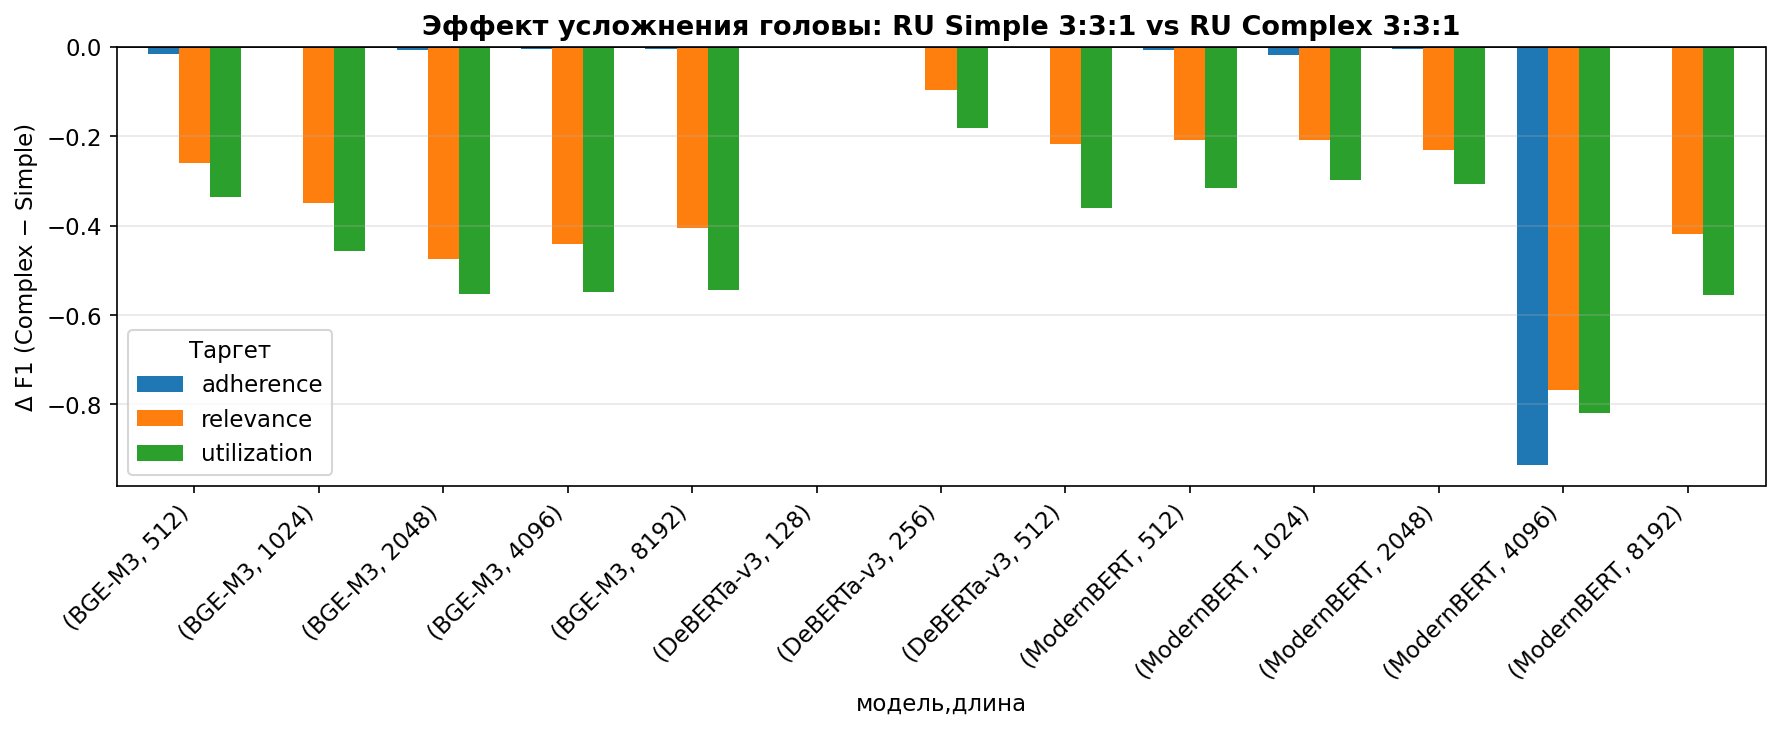

Saved: analysis_output/plots/simple_vs_complex_ru_331_absolute.png


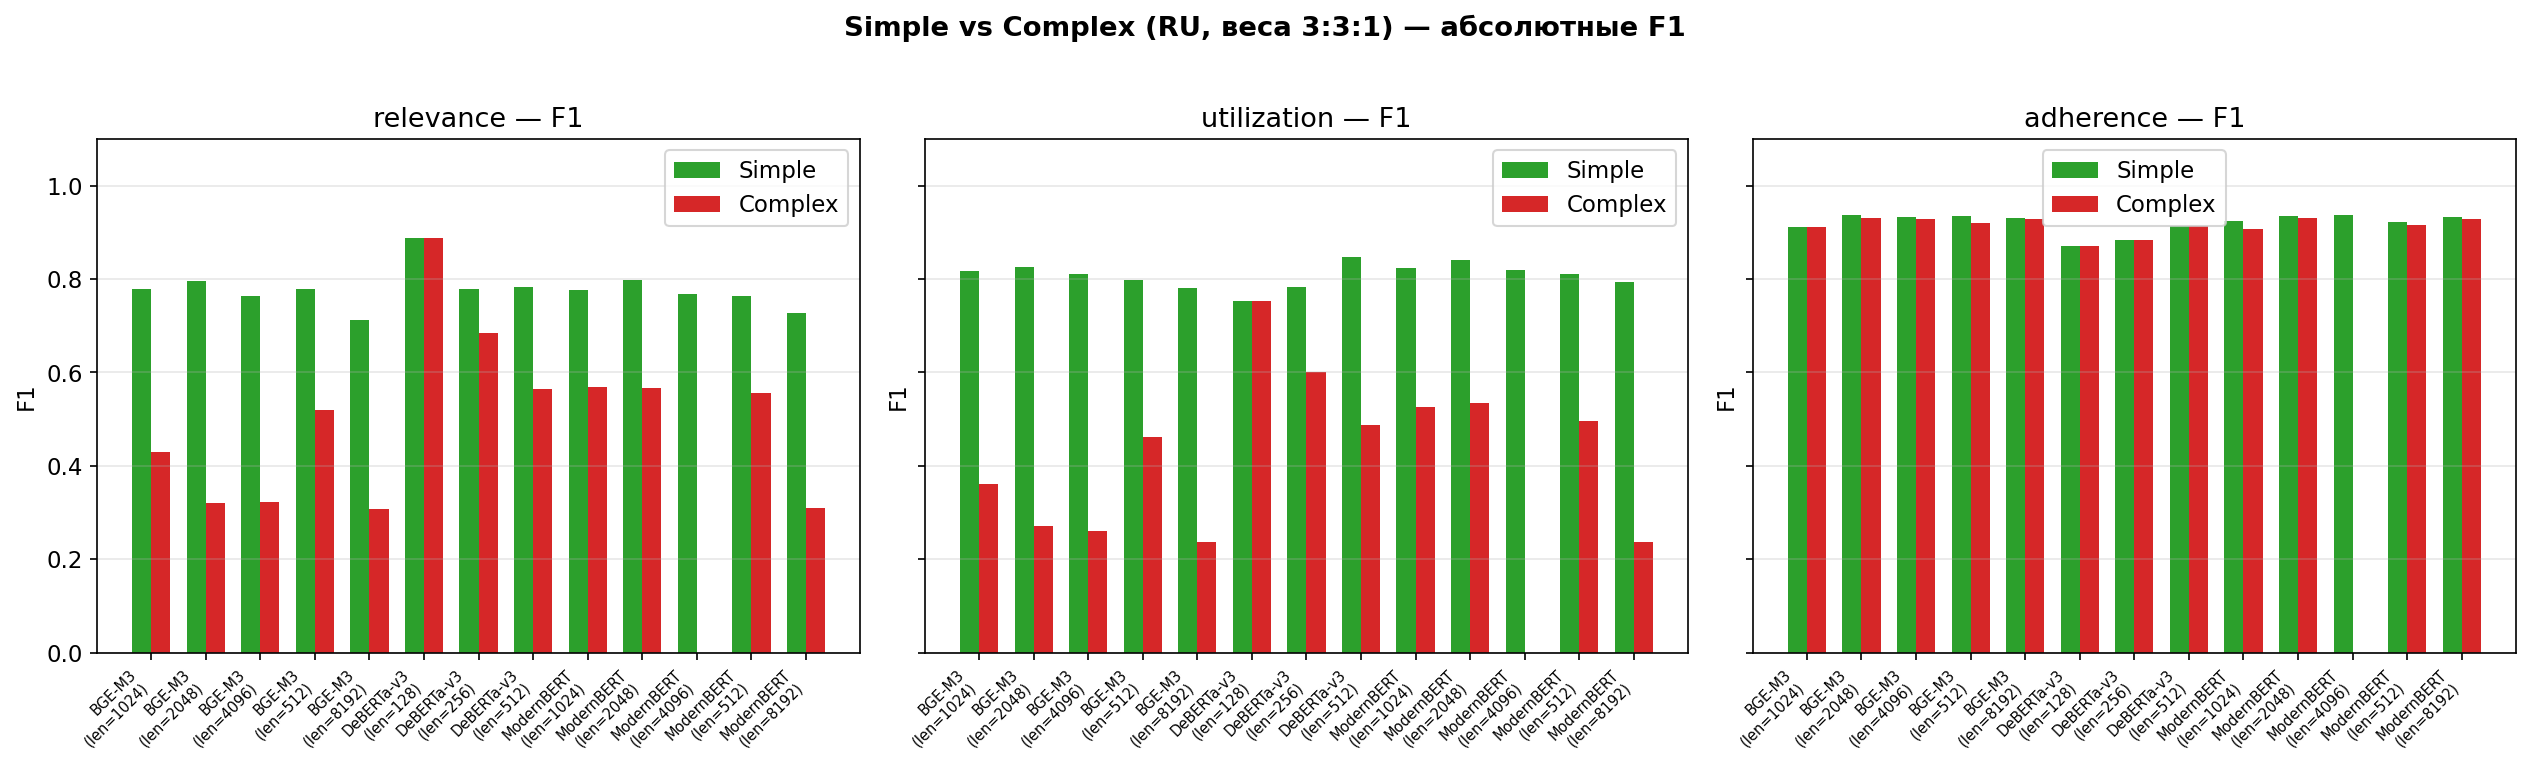

In [30]:

EXP_SIMPLE = "RU Simple 3:3:1"
EXP_COMPLEX = "RU Complex 3:3:1"

if EXP_SIMPLE in df_all["experiment"].values and EXP_COMPLEX in df_all["experiment"].values:
    d_s = df_all[df_all["experiment"] == EXP_SIMPLE].set_index(["model_short", "max_length"])
    d_c = df_all[df_all["experiment"] == EXP_COMPLEX].set_index(["model_short", "max_length"])

    common_idx = d_s.index.intersection(d_c.index)
    if common_idx.empty:
        print(f"[!] Нет общих (модель, длина) для {EXP_SIMPLE} и {EXP_COMPLEX}")
    else:
        rows = []
        for target in TARGETS:
            col = f"test_{target}_f1" if f"test_{target}_f1" in d_s.columns else f"{target}_f1"
            for idx in common_idx:
                v_s = d_s.loc[idx, col]
                v_c = d_c.loc[idx, col]
                if isinstance(v_s, pd.Series): v_s = v_s.iloc[0]
                if isinstance(v_c, pd.Series): v_c = v_c.iloc[0]
                rows.append({
                    "модель": idx[0],
                    "длина": idx[1],
                    "таргет": TARGETS_RU[target],
                    "F1 (Simple)": v_s,
                    "F1 (Complex)": v_c,
                    "Δ (Complex − Simple)": v_c - v_s,
                })

        df_head = pd.DataFrame(rows)

        print(f"\n{'='*70}")
        print(f"  Simple vs Complex head — {EXP_SIMPLE} vs {EXP_COMPLEX}")
        print(f"{'='*70}")
        print("Средняя Δ (Complex − Simple) по таргетам:")
        print(df_head.groupby("таргет")["Δ (Complex − Simple)"].agg(["mean","median"]).round(4).to_string())

        display(
            df_head.style
            .format("{:.4f}", subset=[c for c in df_head.columns if c not in ["модель", "длина", "таргет"]])
            .applymap(
                lambda v: "color: green" if isinstance(v, float) and v > 0.005
                          else ("color: red" if isinstance(v, float) and v < -0.005 else ""),
                subset=["Δ (Complex − Simple)"]
            )
        )

        fig, ax = plt.subplots(figsize=(12, 5))
        pivot_delta = df_head.pivot_table(
            index=["модель", "длина"], columns="таргет", values="Δ (Complex − Simple)"
        )
        pivot_delta.plot(kind="bar", ax=ax, width=0.75)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_ylabel("Δ F1 (Complex − Simple)")
        ax.set_title(f"Эффект усложнения головы: {EXP_SIMPLE} vs {EXP_COMPLEX}", fontweight="bold")
        ax.legend(title="Таргет")
        ax.grid(axis="y", alpha=0.3)
        plt.xticks(rotation=45, ha="right")
        fig.tight_layout()
        fname = OUTPUT_DIR / "plots" / "simple_vs_complex_ru_331.png"
        fig.savefig(fname, bbox_inches="tight")
        print(f"Saved: {fname}")
        plt.show()

        df_head.to_csv(OUTPUT_DIR / "tables" / "simple_vs_complex_ru_331.csv", index=False)

        fig2, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
        for ax, target in zip(axes, TARGETS):
            sub = df_head[df_head["таргет"] == TARGETS_RU[target]].copy()
            sub["label"] = sub["модель"] + "\n(len=" + sub["длина"].astype(str) + ")"
            x = np.arange(len(sub))
            w = 0.35
            ax.bar(x - w/2, sub["F1 (Simple)"],  w, label="Simple",  color=COLORS[2])
            ax.bar(x + w/2, sub["F1 (Complex)"], w, label="Complex", color=COLORS[3])
            ax.set_xticks(x)
            ax.set_xticklabels(sub["label"], fontsize=7, rotation=45, ha="right")
            ax.set_title(f"{TARGETS_RU[target]} — F1")
            ax.set_ylabel("F1")
            ax.set_ylim(0, 1.1)
            ax.legend()
            ax.grid(axis="y", alpha=0.3)
        fig2.suptitle("Simple vs Complex (RU, веса 3:3:1) — абсолютные F1", fontweight="bold", y=1.02)
        fig2.tight_layout()
        fname2 = OUTPUT_DIR / "plots" / "simple_vs_complex_ru_331_absolute.png"
        fig2.savefig(fname2, bbox_inches="tight")
        print(f"Saved: {fname2}")
        plt.show()
else:
    print(f"[!] Нужны оба эксперимента: {EXP_SIMPLE} и {EXP_COMPLEX}")

## 9. Сводный leaderboard и усреднение по эксперименту

Две таблицы:
- **Топ‑5 конфигураций** — лучшие по среднему Test F1 по трём таргетам, по всем 5 экспериментам.
- **Среднее F1 на эксперимент** — агрегированное число на эксперимент, удобно для абзаца‑выжимки.

Топ‑10 конфигураций (по среднему Test F1 из 3 таргетов):


,experiment,lang,head_type,weights,model_short,max_length,mean_test_f1,test_relevance_f1,test_utilization_f1,test_adherence_f1
0,RU Simple 3:3:1,RU,Simple,3:3:1,ModernBERT,2048,0.8578,0.7978,0.8406,0.9349
1,RU Simple 1:1:1,RU,Simple,1:1:1,BGE-M3,2048,0.8539,0.7956,0.8308,0.9352
2,RU Simple 1:1:1,RU,Simple,1:1:1,ModernBERT,2048,0.8535,0.7968,0.8328,0.9309
3,RU Simple 3:3:1,RU,Simple,3:3:1,BGE-M3,2048,0.8526,0.7962,0.8249,0.9368
4,RU Simple 3:3:1,RU,Simple,3:3:1,DeBERTa-v3,512,0.8477,0.7829,0.8467,0.9135
5,RU Simple 1:1:1,RU,Simple,1:1:1,BGE-M3,512,0.8472,0.7938,0.8161,0.9318
6,RU Simple 1:1:1,RU,Simple,1:1:1,ModernBERT,1024,0.8414,0.7769,0.8264,0.9209
7,RU Simple 3:3:1,RU,Simple,3:3:1,ModernBERT,4096,0.8412,0.7682,0.8188,0.9366
8,RU Simple 3:3:1,RU,Simple,3:3:1,ModernBERT,1024,0.8412,0.7757,0.8234,0.9245
9,RU Simple 1:1:1,RU,Simple,1:1:1,DeBERTa-v3,512,0.8406,0.7732,0.8468,0.9018



Усреднение по эксперименту (mean / max по всем моделям и длинам):


mean_test_f1         test_relevance_f1          \
                         mean     max              mean     max   
experiment                                                        
RU Simple 1:1:1        0.8293  0.8539            0.7724  0.8837   
RU Simple 3:3:1        0.8256  0.8578            0.7674  0.8869   
EN Simple 1:1:1        0.6091  0.7244            0.4834  0.6399   
EN Simple 3:3:1        0.5727  0.7467            0.4687  0.6589   
RU Complex 3:3:1       0.5743  0.8363            0.4628  0.8869   

                 test_utilization_f1         test_adherence_f1          
                                mean     max              mean     max  
experiment                                                              
RU Simple 1:1:1               0.7993  0.8468            0.9162  0.9364  
RU Simple 3:3:1               0.7910  0.8467            0.9184  0.9368  
EN Simple 1:1:1               0.4323  0.6267            0.9117  0.9278  
EN Simple 3:3:1               0.3910  0.6590            0.8583  0.9253  
RU Complex 3:3:1              0.3994  0.7519            0.8606  0.9312

Saved: analysis_output/plots/per_experiment_summary.png


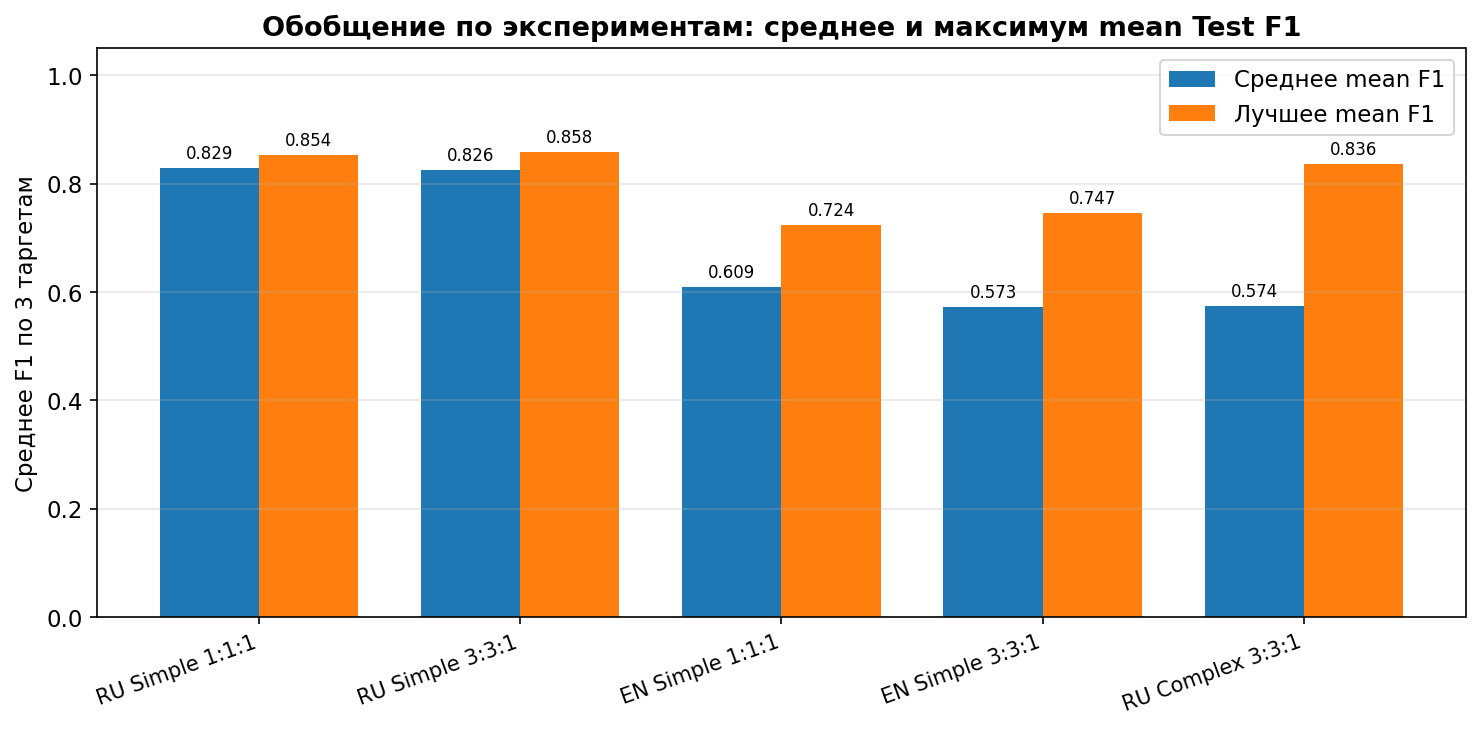

In [31]:

test_cols_present = [c for c in TEST_F1_COLS if c in df_all.columns]
f1_src_cols = test_cols_present if len(test_cols_present) == 3 else F1_COLS

df_lb = df_all.copy()
df_lb["mean_test_f1"] = df_lb[f1_src_cols].mean(axis=1)

top_cols = ["experiment", "lang", "head_type", "weights",
            "model_short", "max_length", "mean_test_f1", *f1_src_cols]
top5 = (
    df_lb[top_cols]
    .sort_values("mean_test_f1", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print("Топ‑10 конфигураций (по среднему Test F1 из 3 таргетов):")
display(
    top5.style
    .format("{:.4f}", subset=["mean_test_f1", *f1_src_cols])
    .background_gradient(cmap="RdYlGn", subset=["mean_test_f1", *f1_src_cols], vmin=0, vmax=1)
)
top5.to_csv(OUTPUT_DIR / "tables" / "leaderboard_top10.csv", index=False)


agg = (
    df_lb.groupby("experiment")[["mean_test_f1", *f1_src_cols]]
         .agg(["mean", "max"])
         .round(4)
)
agg = agg.reindex([e for e in EXPERIMENTS.keys() if e in agg.index])
print("\nУсреднение по эксперименту (mean / max по всем моделям и длинам):")
display(agg)
agg.to_csv(OUTPUT_DIR / "tables" / "per_experiment_summary.csv")


fig, ax = plt.subplots(figsize=(10, 5))
exp_order = [e for e in EXPERIMENTS.keys() if e in df_lb["experiment"].unique()]
means = [df_lb[df_lb["experiment"] == e]["mean_test_f1"].mean() for e in exp_order]
maxes = [df_lb[df_lb["experiment"] == e]["mean_test_f1"].max() for e in exp_order]
x = np.arange(len(exp_order))
w = 0.38
ax.bar(x - w/2, means, w, label="Среднее mean F1", color=COLORS[0])
ax.bar(x + w/2, maxes, w, label="Лучшее mean F1", color=COLORS[1])
for xi, m, M in zip(x, means, maxes):
    ax.text(xi - w/2, m + 0.01, f"{m:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(xi + w/2, M + 0.01, f"{M:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(exp_order, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("Среднее F1 по 3 таргетам")
ax.set_ylim(0, 1.05)
ax.set_title("Обобщение по экспериментам: среднее и максимум mean Test F1", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fname = OUTPUT_DIR / "plots" / "per_experiment_summary.png"
fig.savefig(fname, bbox_inches="tight")
print(f"Saved: {fname}")
plt.show()

## 10. LLM-based baseline (Qwen2.5‑72B) vs классификатор

In [32]:

LLM_METRICS = {
    "covidqa": {
        "train": {"relevant_overlap": 0.7495, "utilized_overlap": 0.8507,
                   "relevant_miss": 1.289, "utilized_miss": 0.492,
                   "relevant_extra": 1.802, "utilized_extra": 0.866},
        "validation": {"relevant_overlap": 0.7768, "utilized_overlap": 0.8822,
                        "relevant_miss": 1.45, "utilized_miss": 0.5,
                        "relevant_extra": 1.425, "utilized_extra": 0.725},
        "test": {"relevant_overlap": 0.7716, "utilized_overlap": 0.8718,
                  "relevant_miss": 1.278, "utilized_miss": 0.417,
                  "relevant_extra": 1.972, "utilized_extra": 1.306},
    },
    "cuad": {
        "train": {"relevant_overlap": 0.7615, "utilized_overlap": 0.7782,
                   "relevant_miss": 0.397, "utilized_miss": 0.353,
                   "relevant_extra": 6.044, "utilized_extra": 2.691},
        "validation": {"relevant_overlap": 0.4591, "utilized_overlap": 0.7895,
                        "relevant_miss": 1.053, "utilized_miss": 0.316,
                        "relevant_extra": 7.105, "utilized_extra": 2.842},
        "test": {"relevant_overlap": 0.6946, "utilized_overlap": 0.8082,
                  "relevant_miss": 0.862, "utilized_miss": 0.828,
                  "relevant_extra": 6.172, "utilized_extra": 4.966},
    },
}

LLM_AGGREGATED = {
    "relevant_overlap_mean": 0.7022,
    "utilized_overlap_mean": 0.8301,
    "relevant_miss_mean": 1.0547,
    "utilized_miss_mean": 0.4842,
    "relevant_extra_mean": 4.0869,
    "utilized_extra_mean": 2.2326,
}

llm_rows = []
for dataset, splits in LLM_METRICS.items():
    for split, metrics in splits.items():
        llm_rows.append({"dataset": dataset, "split": split, **metrics})
df_llm = pd.DataFrame(llm_rows)

print("LLM-based оценка (Qwen2.5‑72B):")
display(df_llm.style.format("{:.4f}", subset=[c for c in df_llm.columns if c not in ["dataset", "split"]]))

print("\n" + "="*70)
print("  Сравнение: Classifier (лучший) vs LLM (Qwen2.5‑72B)")
print("="*70)
print("""
Внимание: метрики НЕ напрямую сравнимы.
  - Classifier: token‑level F1 (precision/recall на уровне токенов)
  - LLM: sentence‑level overlap ratio (доля правильно найденных ключей предложений)

Sentence overlap ≈ Recall на уровне предложений.
Для строгого сравнения нужно привести к единой шкале (агрегировать предсказания
классификатора до уровня предложений).
""")

comparison_rows = []

comparison_rows.append({
    "метод": "Qwen2.5‑72B (LLM)",
    "relevance (sentence overlap)": LLM_AGGREGATED["relevant_overlap_mean"],
    "utilization (sentence overlap)": LLM_AGGREGATED["utilized_overlap_mean"],
    "relevance miss (avg)": LLM_AGGREGATED["relevant_miss_mean"],
    "utilization miss (avg)": LLM_AGGREGATED["utilized_miss_mean"],
})


if "RU Simple 1:1:1" in df_all["experiment"].values:
    ru_best = df_all[df_all["experiment"] == "RU Simple 1:1:1"]
    idx = ru_best.groupby("model_short")["best_val_f1"].idxmax()
    for i in idx:
        row = ru_best.loc[i]
        rel_col = "test_relevance_f1" if "test_relevance_f1" in row.index else "relevance_f1"
        util_col = "test_utilization_f1" if "test_utilization_f1" in row.index else "utilization_f1"
        comparison_rows.append({
            "метод": f"{row['model_short']} (len={int(row['max_length'])}, RU Simple 1:1:1)",
            "relevance (token F1)": row.get(rel_col, np.nan),
            "utilization (token F1)": row.get(util_col, np.nan),
        })

df_compare = pd.DataFrame(comparison_rows)
display(df_compare.style.format("{:.4f}", na_rep="—"))
df_compare.to_csv(OUTPUT_DIR / "tables" / "classifier_vs_llm.csv", index=False)

LLM-based оценка (Qwen2.5‑72B):


,dataset,split,relevant_overlap,utilized_overlap,relevant_miss,utilized_miss,relevant_extra,utilized_extra
0,covidqa,train,0.7495,0.8507,1.2890,0.4920,1.8020,0.8660
1,covidqa,validation,0.7768,0.8822,1.4500,0.5000,1.4250,0.7250
2,covidqa,test,0.7716,0.8718,1.2780,0.4170,1.9720,1.3060
3,cuad,train,0.7615,0.7782,0.3970,0.3530,6.0440,2.6910
4,cuad,validation,0.4591,0.7895,1.0530,0.3160,7.1050,2.8420
5,cuad,test,0.6946,0.8082,0.8620,0.8280,6.1720,4.9660



  Сравнение: Classifier (лучший) vs LLM (Qwen2.5‑72B)

Внимание: метрики НЕ напрямую сравнимы.
  - Classifier: token‑level F1 (precision/recall на уровне токенов)
  - LLM: sentence‑level overlap ratio (доля правильно найденных ключей предложений)

Sentence overlap ≈ Recall на уровне предложений.
Для строгого сравнения нужно привести к единой шкале (агрегировать предсказания
классификатора до уровня предложений).



ValueError: Unknown format code 'f' for object of type 'str'

## 11. Анализ оптимальных порогов

Оптимальные пороги (подобраны на validation):



,experiment,lang,head_type,weights,model_short,max_length,threshold_relevance,threshold_utilization,threshold_adherence
0,EN Simple 1:1:1,EN,Simple,1:1:1,BGE-M3,512,0.10,0.10,0.10
1,EN Simple 1:1:1,EN,Simple,1:1:1,BGE-M3,1024,0.10,0.10,0.10
2,EN Simple 1:1:1,EN,Simple,1:1:1,BGE-M3,2048,0.10,0.10,0.10
3,EN Simple 1:1:1,EN,Simple,1:1:1,BGE-M3,4096,0.10,0.10,0.10
4,EN Simple 1:1:1,EN,Simple,1:1:1,BGE-M3,8192,0.10,0.10,0.10
5,EN Simple 1:1:1,EN,Simple,1:1:1,DeBERTa-v3,128,0.10,0.10,0.10
6,EN Simple 1:1:1,EN,Simple,1:1:1,DeBERTa-v3,256,0.10,0.10,0.10
7,EN Simple 1:1:1,EN,Simple,1:1:1,DeBERTa-v3,512,0.10,0.10,0.10
8,EN Simple 1:1:1,EN,Simple,1:1:1,ModernBERT,512,0.30,0.20,0.10
9,EN Simple 1:1:1,EN,Simple,1:1:1,ModernBERT,1024,0.40,0.40,0.60


Saved: analysis_output/plots/threshold_boxplots.png


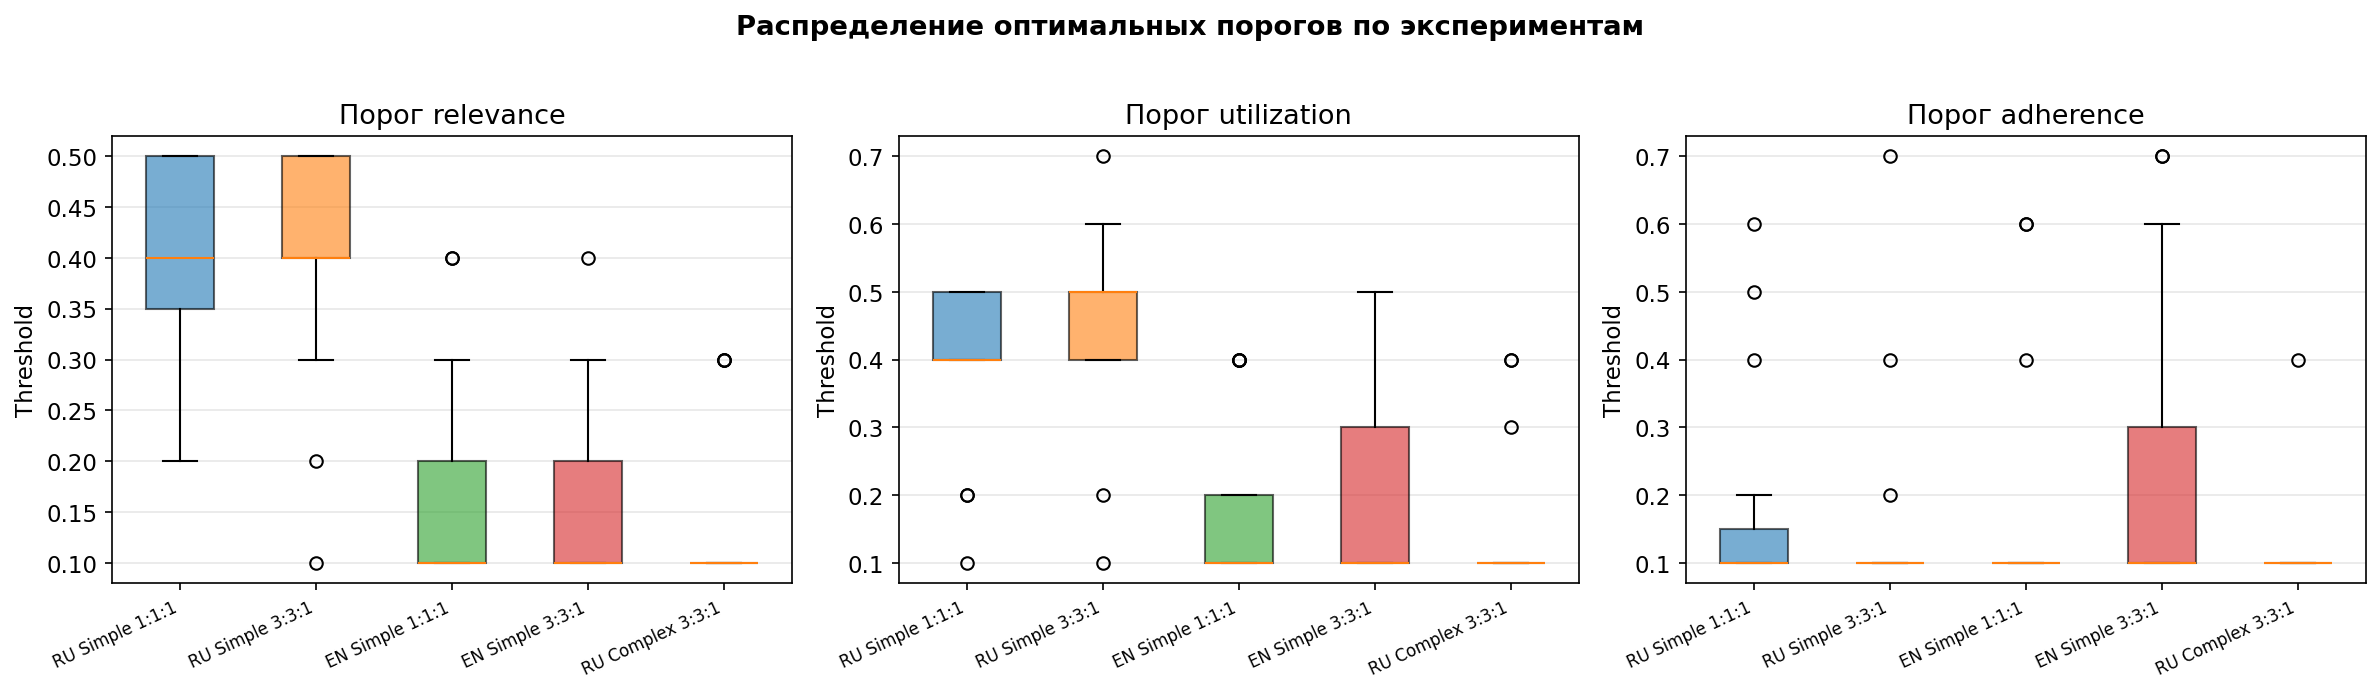

In [33]:

thr_cols = ["threshold_relevance", "threshold_utilization", "threshold_adherence"]
available_thr = [c for c in thr_cols if c in df_all.columns]

if available_thr:
    print("Оптимальные пороги (подобраны на validation):\n")
    thr_show = ["experiment", "lang", "head_type", "weights", "model_short", "max_length"] + available_thr
    thr_show = [c for c in thr_show if c in df_all.columns]
    display(
        df_all[thr_show]
        .sort_values(["experiment", "model_short", "max_length"])
        .reset_index(drop=True)
        .style.format("{:.2f}", subset=available_thr)
        .background_gradient(cmap="YlOrRd", subset=available_thr, vmin=0.1, vmax=0.7)
    )

    exp_order = [e for e in EXPERIMENTS.keys() if e in df_all["experiment"].unique()]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for ax, col in zip(axes, available_thr):
        target_name = col.replace("threshold_", "")
        data_by_exp = [df_all[df_all["experiment"] == exp][col].dropna().values
                       for exp in exp_order]
        bp = ax.boxplot(data_by_exp, labels=exp_order, patch_artist=True)
        for patch, color in zip(bp["boxes"], COLORS):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        ax.set_title(f"Порог {TARGETS_RU.get(target_name, target_name)}")
        ax.set_ylabel("Threshold")
        ax.grid(axis="y", alpha=0.3)
        plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

    fig.suptitle("Распределение оптимальных порогов по экспериментам", fontweight="bold", y=1.02)
    fig.tight_layout()
    fname = OUTPUT_DIR / "plots" / "threshold_boxplots.png"
    fig.savefig(fname, bbox_inches="tight")
    print(f"Saved: {fname}")
    plt.show()

    df_all[thr_show].to_csv(OUTPUT_DIR / "tables" / "thresholds.csv", index=False)
else:
    print("Пороги не найдены в данных (threshold_* колонки отсутствуют)")

## 12. Precision / Recall scatter

Цвет = эксперимент, маркер: ○ = Simple head, ◆ = Complex head.

Saved: analysis_output/plots/precision_recall_scatter.png


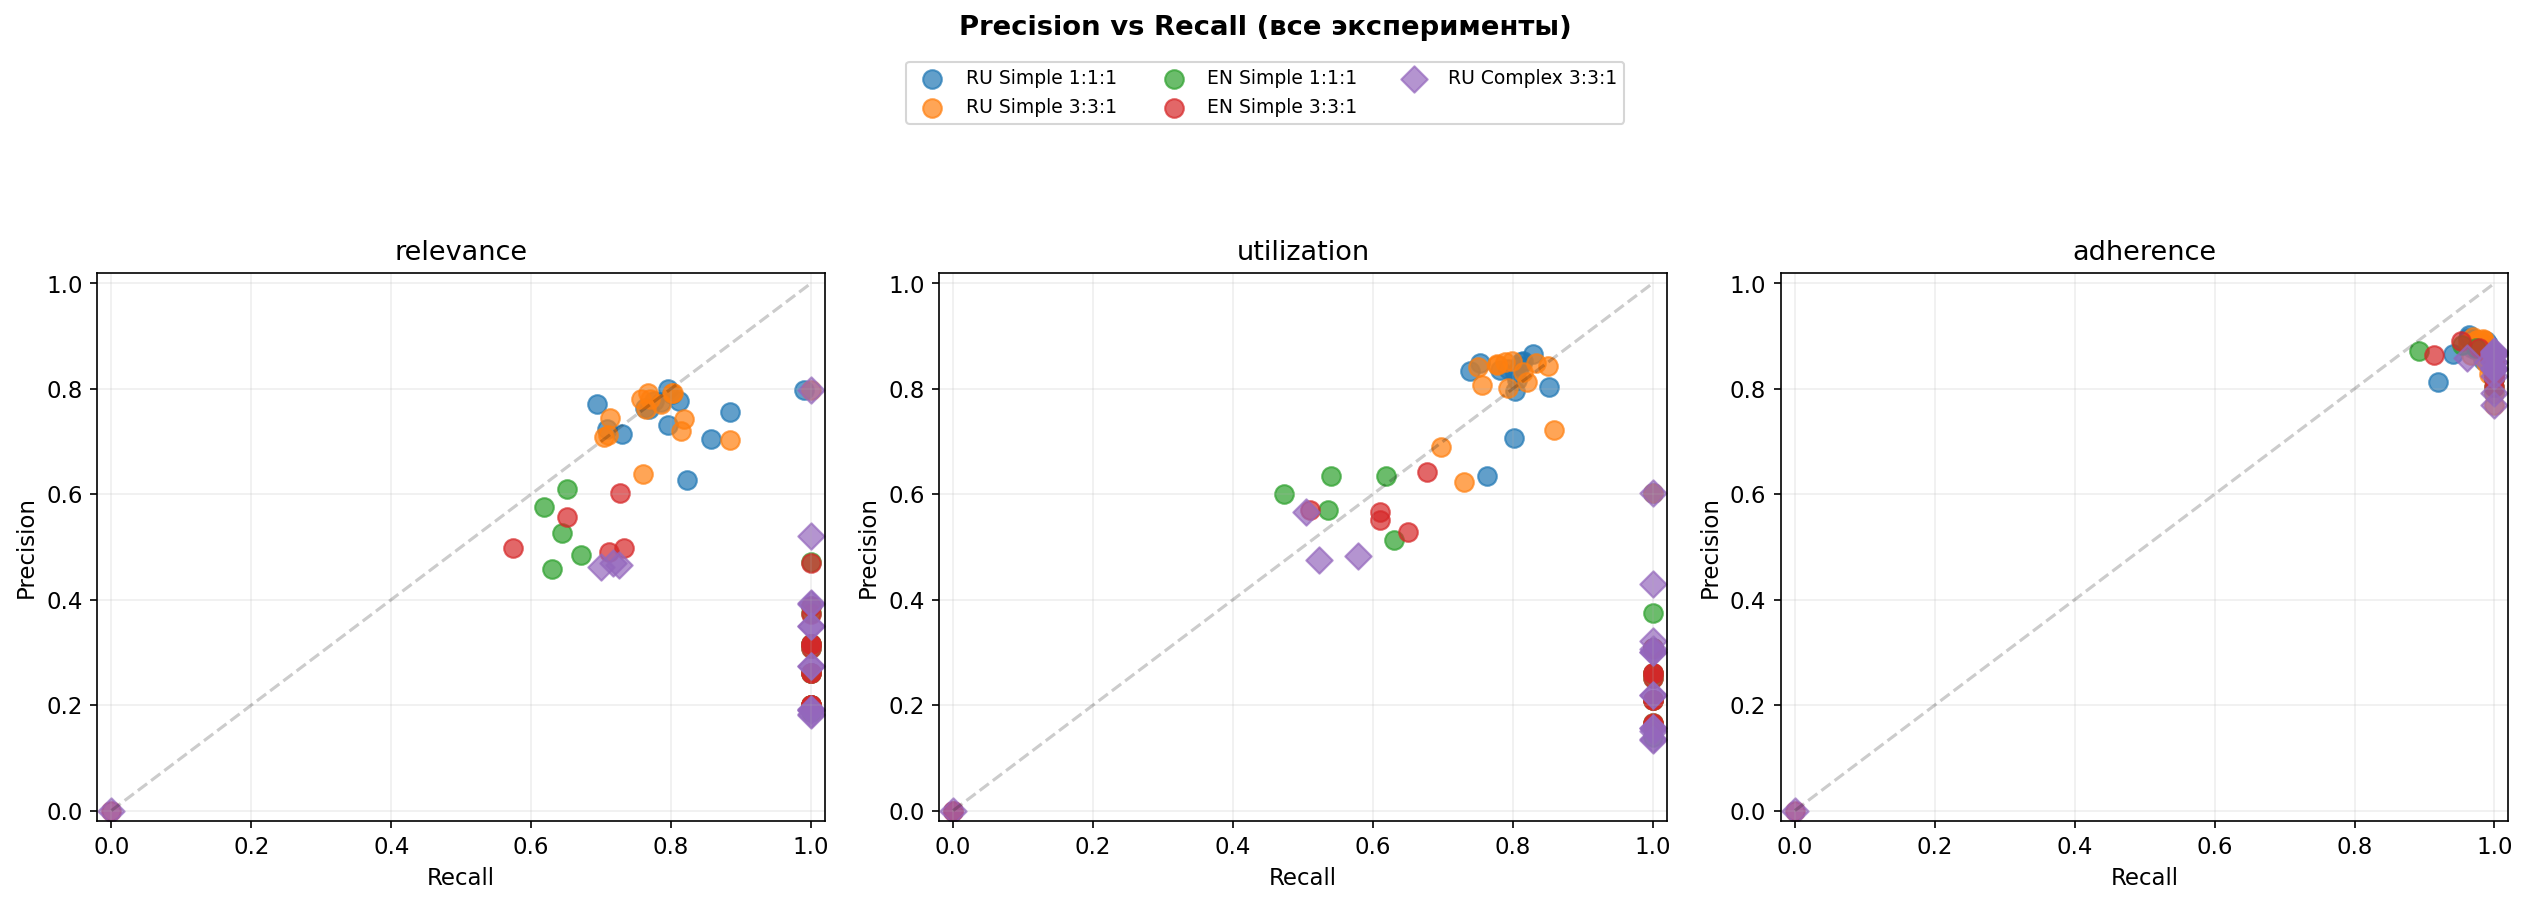

In [34]:

HEAD_MARKER = {"Simple": "o", "Complex": "D"}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

exp_order = [e for e in EXPERIMENTS.keys() if e in df_all["experiment"].unique()]
exp_color = {exp: COLORS[i % len(COLORS)] for i, exp in enumerate(exp_order)}

for ax, target in zip(axes, TARGETS):
    p_col = f"test_{target}_precision" if f"test_{target}_precision" in df_all.columns else f"{target}_precision"
    r_col = f"test_{target}_recall"    if f"test_{target}_recall"    in df_all.columns else f"{target}_recall"

    if p_col not in df_all.columns or r_col not in df_all.columns:
        ax.set_title(f"{TARGETS_RU[target]} (нет данных)")
        continue

    for exp in exp_order:
        g = df_all[df_all["experiment"] == exp]
        if g.empty:
            continue
        head = g["head_type"].iloc[0]
        ax.scatter(
            g[r_col], g[p_col],
            marker=HEAD_MARKER.get(head, "o"),
            color=exp_color[exp],
            s=80, alpha=0.7,
            label=exp if target == TARGETS[0] else None,
        )

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(TARGETS_RU[target])
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.2)
    ax.grid(True, alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.15), fontsize=9)
fig.suptitle("Precision vs Recall (все эксперименты)", fontweight="bold", y=1.2)
fig.tight_layout()
fname = OUTPUT_DIR / "plots" / "precision_recall_scatter.png"
fig.savefig(fname, bbox_inches="tight")
print(f"Saved: {fname}")
plt.show()

## 13. LaTeX-таблицы

In [35]:
def df_to_latex(df, caption, label, float_fmt="{:.4f}"):
    """Генерирует LaTeX-таблицу из DataFrame."""
    formatters = {}
    for col in df.columns:
        if df[col].dtype in [np.float64, np.float32]:
            formatters[col] = lambda x, fmt=float_fmt: fmt.format(x) if pd.notna(x) else "—"

    latex = df.to_latex(
        index=False,
        formatters=formatters,
        caption=caption,
        label=label,
        escape=True,
        column_format="l" + "c" * (len(df.columns) - 1),
    )
    return latex


# 1) Лучшие конфигурации по RU экспериментам
if any(df_all["lang"] == "RU"):
    ru_data = df_all[df_all["lang"] == "RU"]
    idx = ru_data.groupby(["experiment", "model_short"])["best_val_f1"].idxmax()
    best_ru = ru_data.loc[idx]

    cols_for_latex = ["experiment", "head_type", "weights", "model_short", "max_length", "best_val_f1"]
    for t in TARGETS:
        test_col = f"test_{t}_f1"
        val_col = f"{t}_f1"
        cols_for_latex.append(test_col if test_col in best_ru.columns else val_col)
    cols_for_latex = [c for c in cols_for_latex if c in best_ru.columns]
    # print(best_ru[cols_for_latex].columns)
    latex_table = best_ru[cols_for_latex].sort_values(
        ["head_type", "weights", "best_val_f1"], ascending=[True, True, False]
    )
    rename = {"experiment": "Experiment", "head_type": "Head", "weights": "Weights",
              "model_short": "Model", "max_length": "Max Len"}
    for t in TARGETS:
        rename[f"test_{t}_f1"] = f"{t.capitalize()} F1"
        rename[f"{t}_f1"] = f"{t.capitalize()} F1"

    latex_str = df_to_latex(
        latex_table.rename(columns=rename),
        caption="Лучшие конфигурации моделей на русскоязычном RAGBench (Test F1)",
        label="tab:best_ru_results",
    )
    print(latex_str)
    with open(OUTPUT_DIR / "tables" / "best_ru_results.tex", "w", encoding="utf-8") as f:
        f.write(latex_str)
    print(f"Saved: {OUTPUT_DIR / 'tables' / 'best_ru_results.tex'}")


# 2) Classifier vs LLM
if len(comparison_rows) > 0:
    latex_str2 = df_to_latex(
        df_compare,
        caption="Сравнение токен-классификатора и LLM-based оценки (Qwen2.5‑72B)",
        label="tab:classifier_vs_llm",
    )
    print("\n" + latex_str2)
    with open(OUTPUT_DIR / "tables" / "classifier_vs_llm.tex", "w", encoding="utf-8") as f:
        f.write(latex_str2)
    print(f"Saved: {OUTPUT_DIR / 'tables' / 'classifier_vs_llm.tex'}")


# 3) Simple vs Complex head (RU 3:3:1)
sv_csv = OUTPUT_DIR / "tables" / "simple_vs_complex_ru_331.csv"
if sv_csv.exists():
    df_sv = pd.read_csv(sv_csv)
    latex_str3 = df_to_latex(
        df_sv,
        caption="Simple vs Complex head на RU (веса 3:3:1): Δ F1 по таргетам",
        label="tab:simple_vs_complex",
    )
    print("\n" + latex_str3)
    with open(OUTPUT_DIR / "tables" / "simple_vs_complex_ru_331.tex", "w", encoding="utf-8") as f:
        f.write(latex_str3)
    print(f"Saved: {OUTPUT_DIR / 'tables' / 'simple_vs_complex_ru_331.tex'}")


# 4) Топ-10 leaderboard
lb_csv = OUTPUT_DIR / "tables" / "leaderboard_top10.csv"
if lb_csv.exists():
    df_lb_l = pd.read_csv(lb_csv)
    latex_str4 = df_to_latex(
        df_lb_l,
        caption="Топ-10 конфигураций по среднему Test F1 (по всем экспериментам)",
        label="tab:leaderboard_top10",
    )
    print("\n" + latex_str4)
    with open(OUTPUT_DIR / "tables" / "leaderboard_top10.tex", "w", encoding="utf-8") as f:
        f.write(latex_str4)
    print(f"Saved: {OUTPUT_DIR / 'tables' / 'leaderboard_top10.tex'}")

\begin{table}
\caption{Лучшие конфигурации моделей на русскоязычном RAGBench (Test F1)}
\label{tab:best_ru_results}
\begin{tabular}{lcccccccc}
\toprule
Experiment & Head & Weights & Model & Max Len & best\_val\_f1 & Relevance F1 & Utilization F1 & Adherence F1 \\
\midrule
RU Complex 3:3:1 & Complex & 3:3:1 & DeBERTa-v3 & 128 & 0.9519 & 0.8869 & 0.7519 & 0.8700 \\
RU Complex 3:3:1 & Complex & 3:3:1 & Tochka-AI/ruRoPEBert-e5-base-2k & 256 & 0.6534 & 0.5637 & 0.4696 & 0.9039 \\
RU Complex 3:3:1 & Complex & 3:3:1 & ModernBERT & 512 & 0.6116 & 0.5569 & 0.4962 & 0.9155 \\
RU Complex 3:3:1 & Complex & 3:3:1 & BGE-M3 & 512 & 0.5357 & 0.5187 & 0.4620 & 0.9191 \\
RU Simple 1:1:1 & Simple & 1:1:1 & DeBERTa-v3 & 128 & 0.9536 & 0.8837 & 0.7519 & 0.8625 \\
RU Simple 1:1:1 & Simple & 1:1:1 & ModernBERT & 2048 & 0.8034 & 0.7968 & 0.8328 & 0.9309 \\
RU Simple 1:1:1 & Simple & 1:1:1 & BGE-M3 & 2048 & 0.8008 & 0.7956 & 0.8308 & 0.9352 \\
RU Simple 3:3:1 & Simple & 3:3:1 & DeBERTa-v3 & 128 & 0.9519 & 0.88

## 14. Сводка: все сохранённые артефакты

In [36]:

print("Сохранённые артефакты:\n")
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        size_kb = p.stat().st_size / 1024
        print(f"  {p.relative_to(OUTPUT_DIR)}  ({size_kb:.1f} KB)")

print(f"\nВсего запусков в анализе: {len(df_all)}")
print(f"Эксперименты: {df_all['experiment'].unique().tolist()}")
print(f"Языки:        {df_all['lang'].unique().tolist()}")
print(f"Головы:       {df_all['head_type'].unique().tolist()}")
print(f"Модели:       {df_all['model_short'].unique().tolist()}")
print(f"Длины:        {sorted(df_all['max_length'].unique().tolist())}")

Сохранённые артефакты:

  plots/.ipynb_checkpoints/ablation_weights_EN_Simple_111_vs_EN_Simple_331-checkpoint.png  (320.6 KB)
  plots/.ipynb_checkpoints/ablation_weights_RU_Simple_111_vs_RU_Simple_331-checkpoint.png  (251.7 KB)
  plots/.ipynb_checkpoints/best_models_bar_EN_Simple_111-checkpoint.png  (143.3 KB)
  plots/.ipynb_checkpoints/best_models_bar_EN_Simple_331-checkpoint.png  (143.2 KB)
  plots/.ipynb_checkpoints/best_models_bar_RU_Complex_331-checkpoint.png  (145.1 KB)
  plots/.ipynb_checkpoints/best_models_bar_RU_Simple_111-checkpoint.png  (120.9 KB)
  plots/.ipynb_checkpoints/best_models_bar_RU_Simple_331-checkpoint.png  (123.1 KB)
  plots/.ipynb_checkpoints/f1_vs_length_EN_Simple_111-checkpoint.png  (238.1 KB)
  plots/ablation_weights_EN_Simple_111_vs_EN_Simple_331.png  (315.5 KB)
  plots/ablation_weights_RU_Simple_111_vs_RU_Simple_331.png  (246.9 KB)
  plots/best_models_bar_EN_Simple_111.png  (137.7 KB)
  plots/best_models_bar_EN_Simple_331.png  (138.5 KB)
  plots/best_model